<a href="https://colab.research.google.com/github/simonstryszak/Vancomycin-Treatment-Model/blob/main/Vancomycin_Treatment_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PK-PD Model of Vancomycin Treatment Course for MRSA

##Mathematical Model


$$\frac{dAR_{off}}{dt} = -k_{on}\times A\times AR_{off} + k_{off} \times AR_{on} $$

$$\frac{dAR_{on}}{dt} = k_{on}\times A\times AR_{off} - k_{off} \times AR_{on}$$

$$AR_{eff} = 1 + Slp_{AR} \times AR_{on}$$

$$EC_{50} = EC_{50,0}\times AR_{eff}$$

$$Eff_{drug} = \frac{E_{max}\times A^\gamma}{EC_{50}^\gamma + A}$$

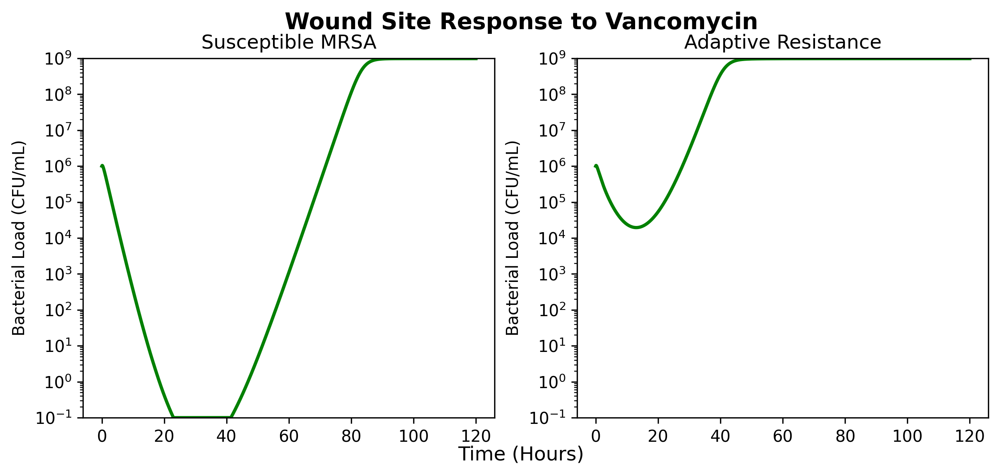

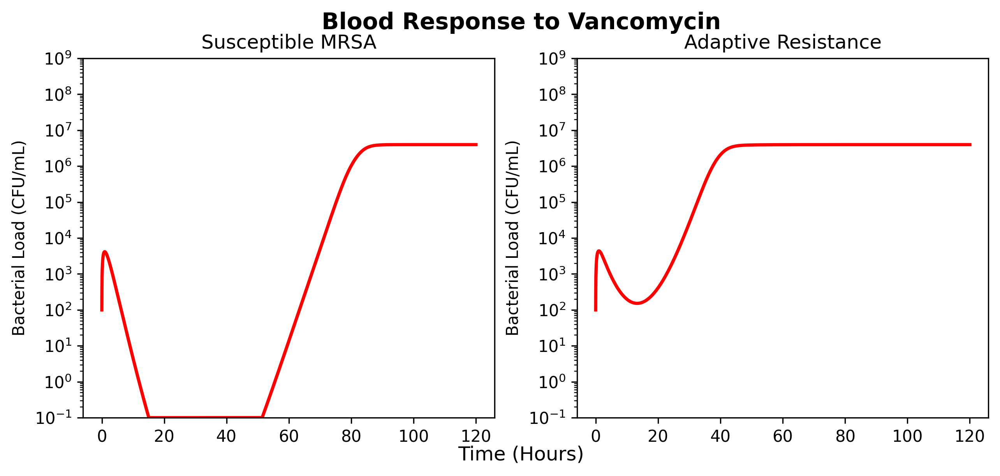

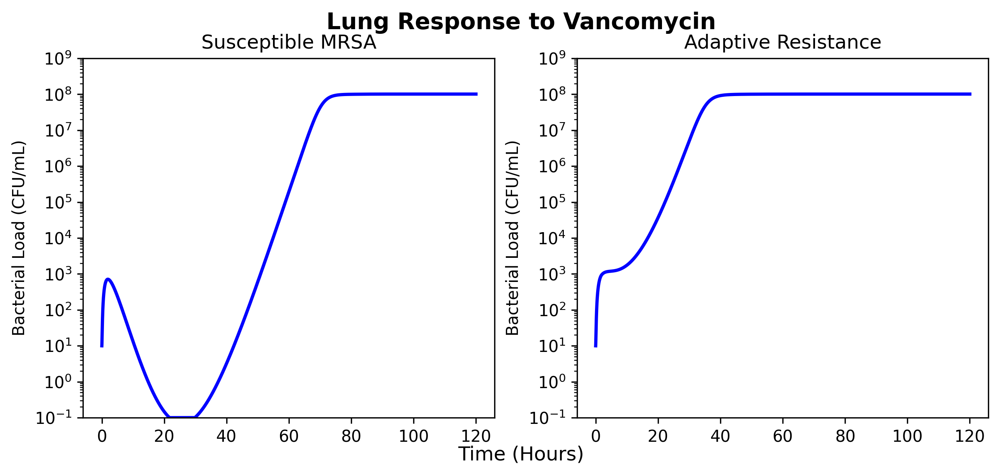

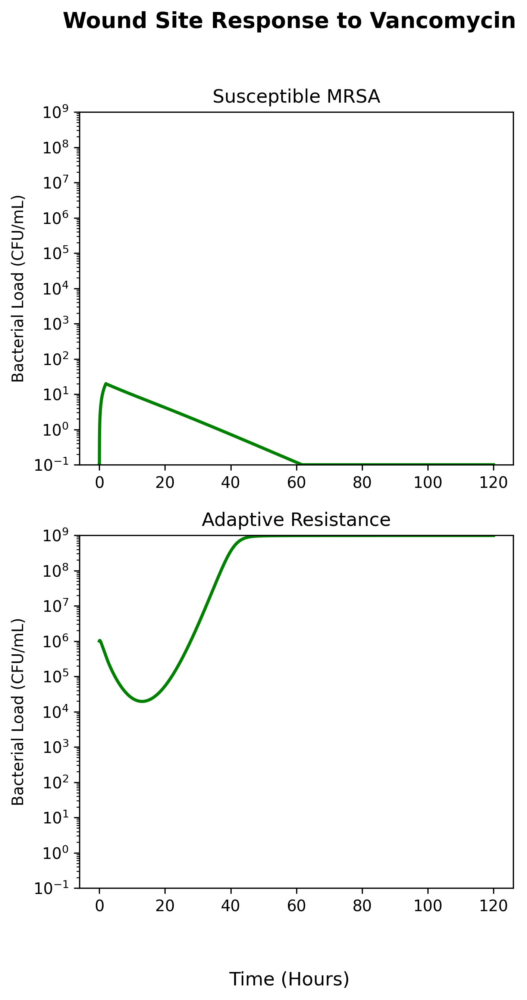

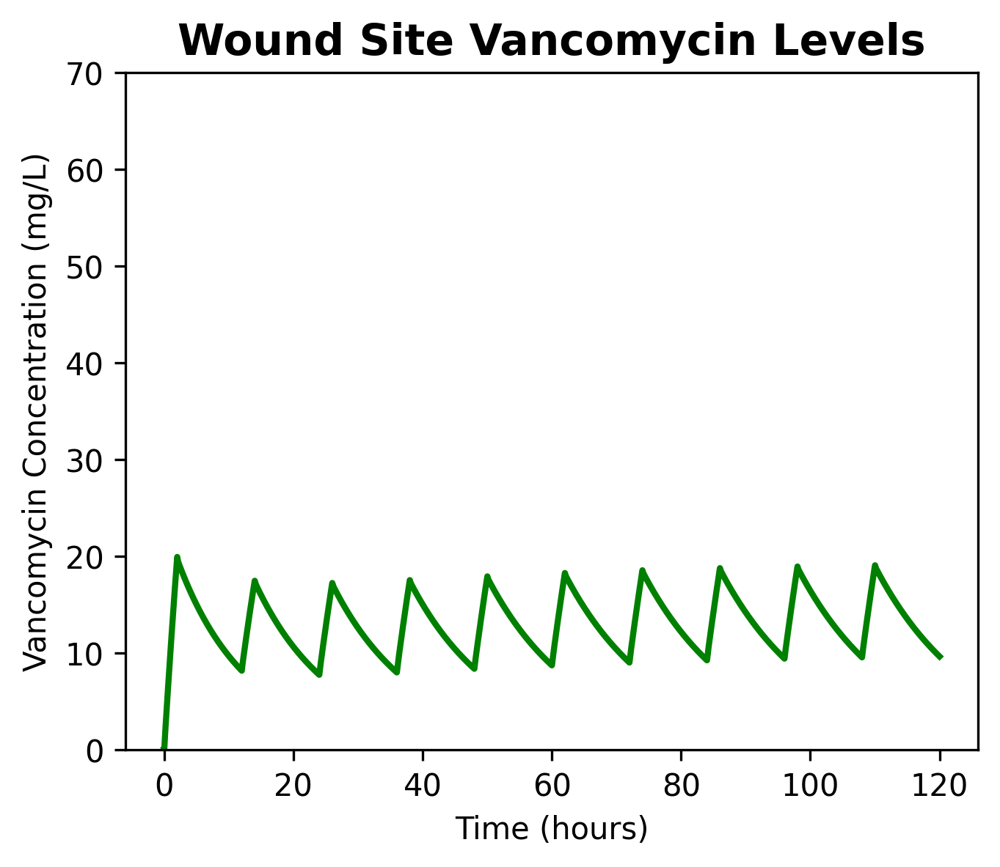

...

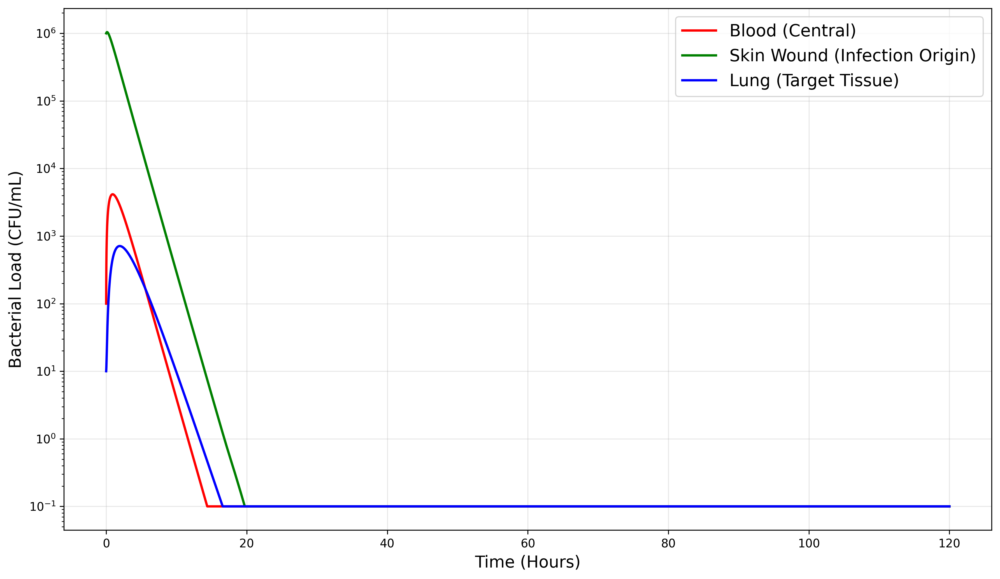

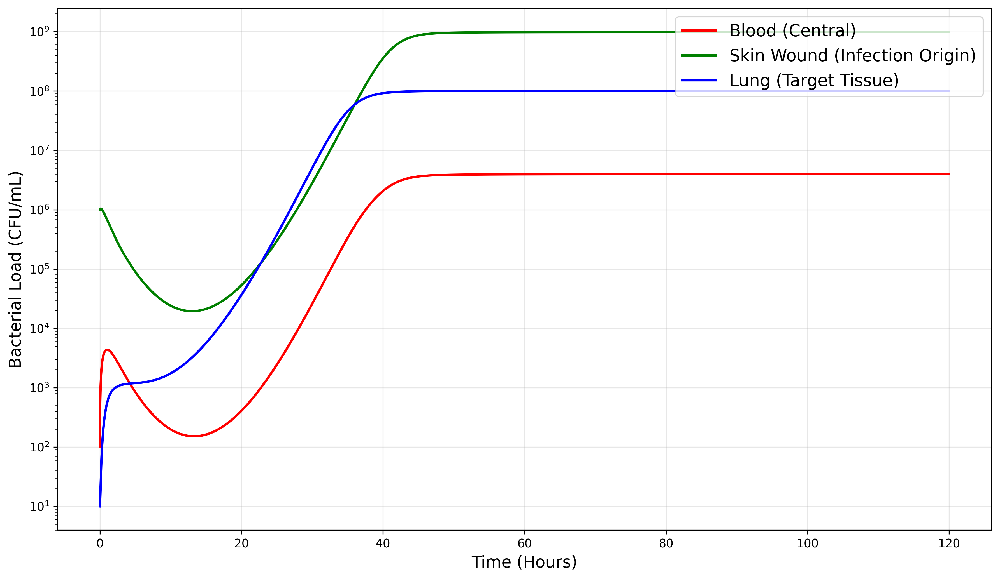

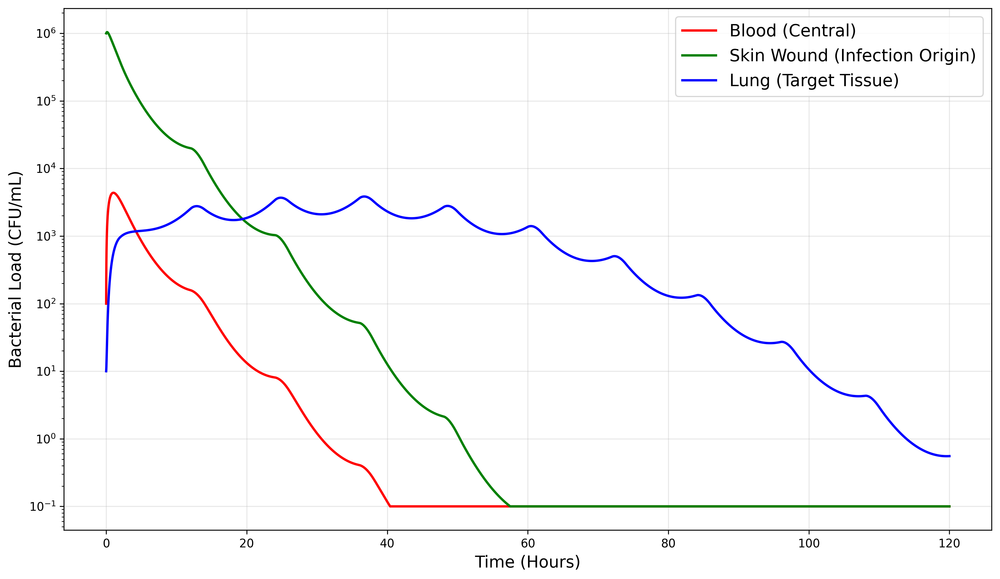

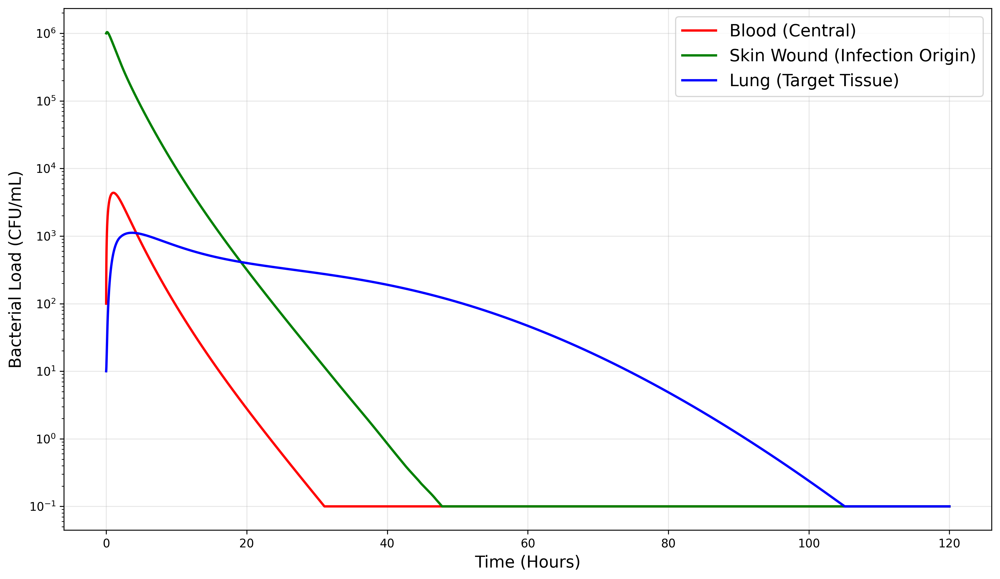

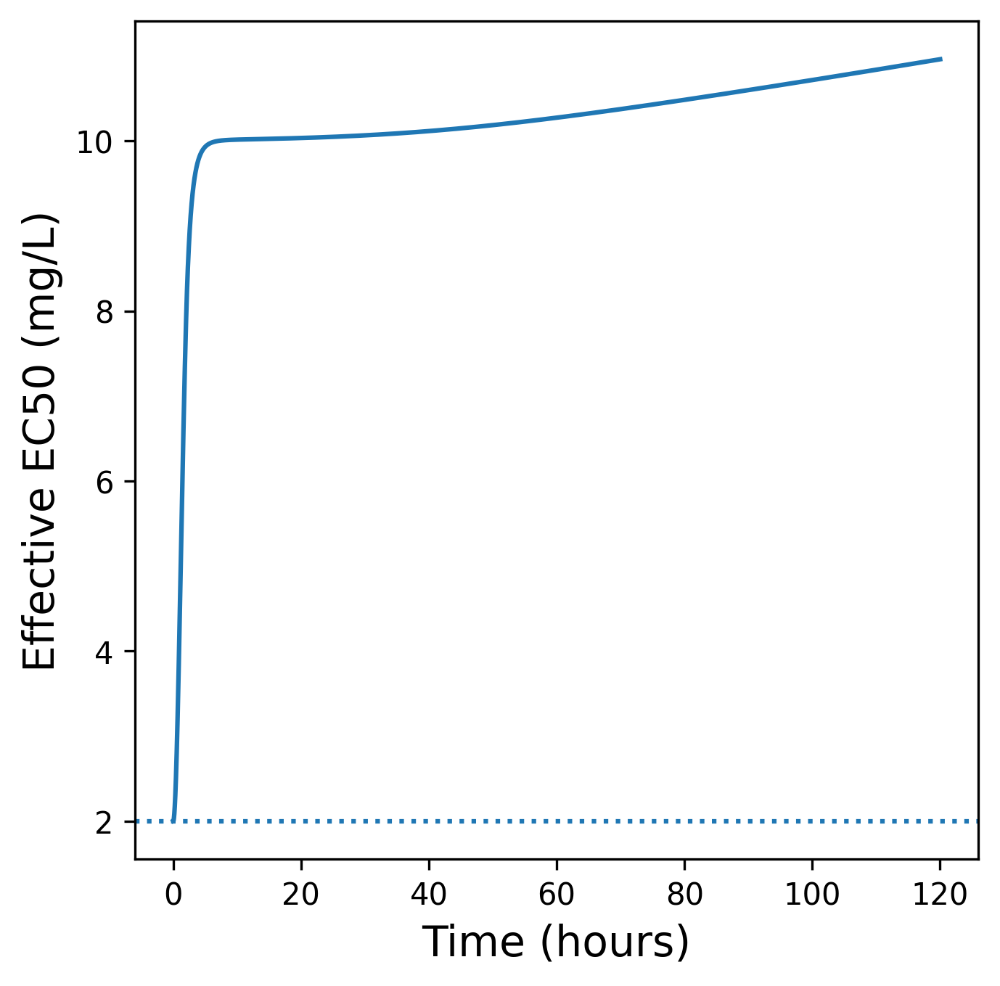

<Figure size 1500x1500 with 0 Axes>

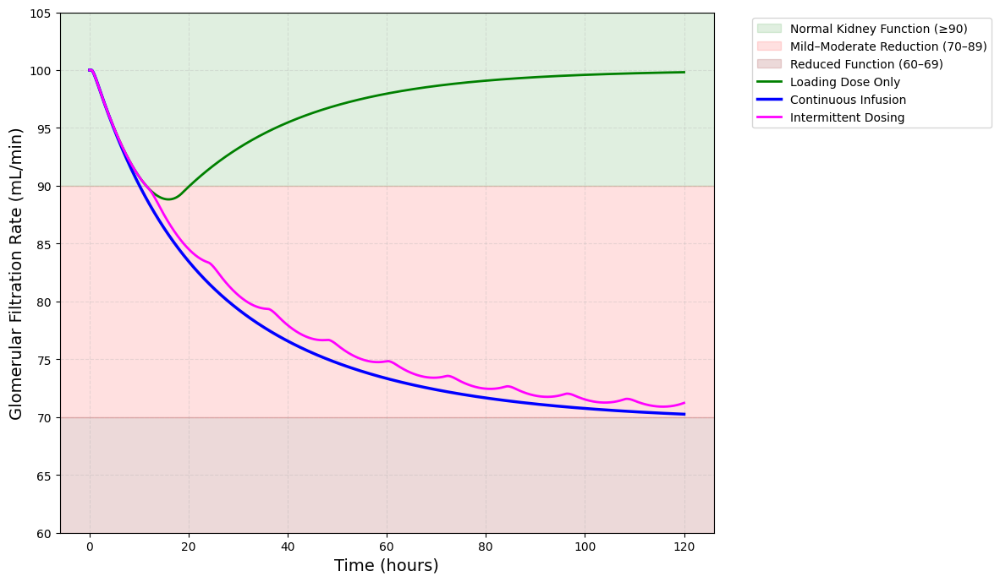

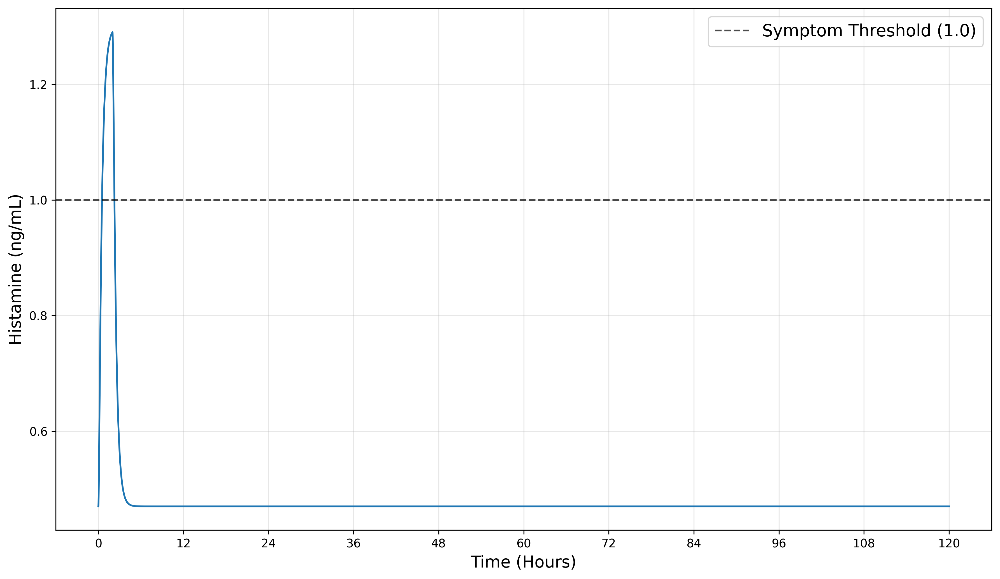

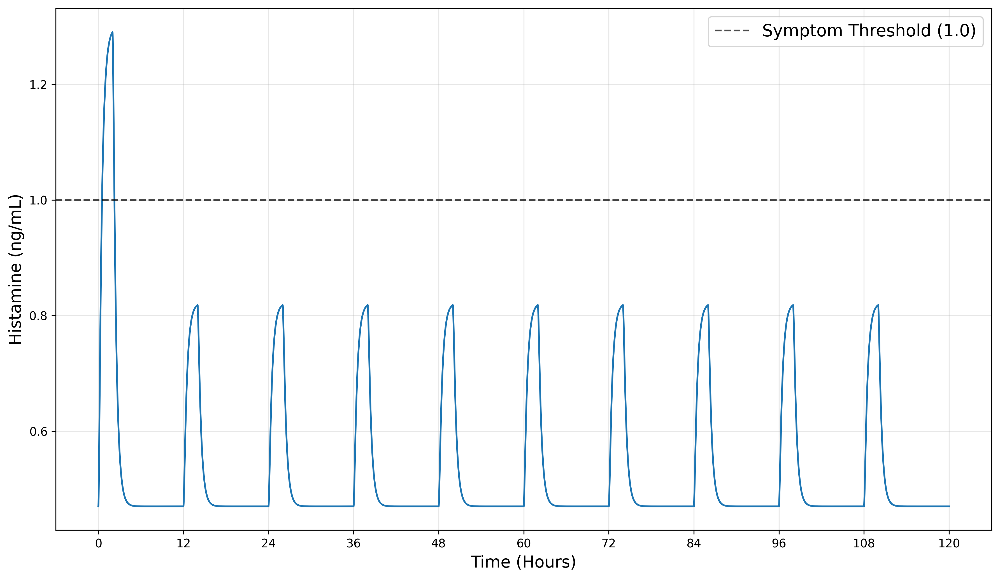

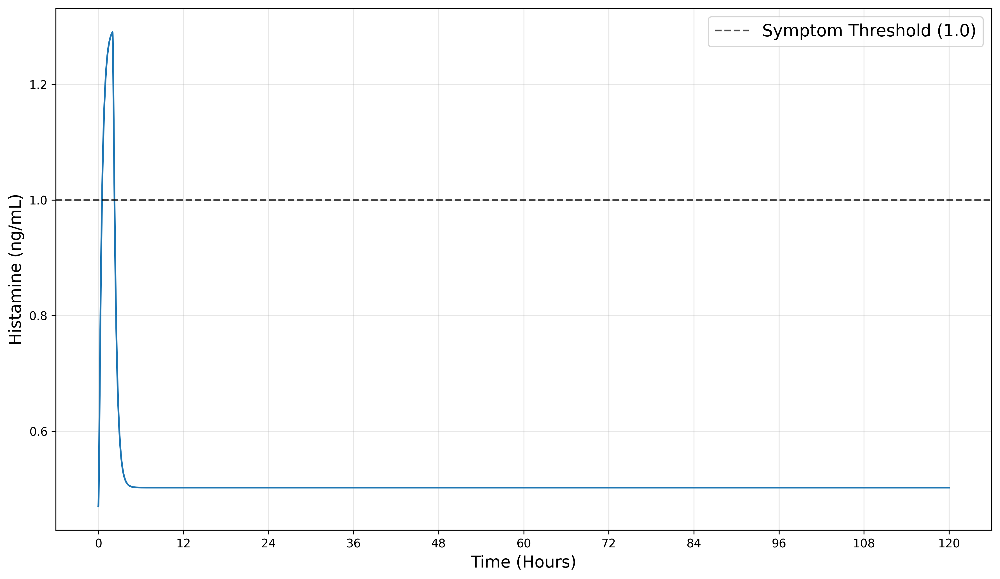

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

Vc = 5.3 # Central Volume (0.07 L/kg * 70kg): SHC
# kel = 0.104



def dose_loading_cons(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 0.0

  # 2) Continuous infusion: 1350 mg per 24h (15 mg/kg)
def dose_continuous_cons(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 1680.0 / 24.0  # mg/hr

  # 3) Intermittent dosing: 1350 mg over 2 hr every 12h (0–1, 12–13, 24–25, ...)
def dose_intermittent_cons(t):
    # Doses at 0, 12, 24, 36, 48, 60, 72 hours
    cycle_time = t % 12
    if t<=2:
        return 1000.0
    elif 0 <= cycle_time < 2:
        return 420.0  # 750mg/hr * 2hr = 1500mg
    return 0.0

def dose_loading(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 0.0

  # 2) Continuous infusion: 1350 mg per 24h (15 mg/kg)
def dose_continuous(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 2100.0 / 24.0  # mg/hr

  # 3) Intermittent dosing: 1350 mg over 2 hr every 12h (0–1, 12–13, 24–25, ...)
def dose_intermittent(t):
    # Doses at 0, 12, 24, 36, 48, 60, 72 hours
    cycle_time = t % 12
    if t<=2:
        return 1000.0
    elif 0 <= cycle_time < 2:
        return 525.0  # 750mg/hr * 2hr = 1500mg
    return 0.0

def vanco_mrsa_model(y,t,params,dose_fn):
  #PK related parameters
  input_term = dose_fn(t) / Vc
  Cb, Cs, Ck, Cl, P_wound, P_blood, P_lung, AR_on_wound, AR_off_wound, AR_on_blood, AR_off_blood, AR_on_lung, AR_off_lung, GFR, Crob, H_slow, H_fast = y
      #mass of drug in compartment (mg)
  V_skin, V_kidney, V_lung, V_rob = params['V'] #volume of compartments (L)
  Kp_skin, Kp_kidney, Kp_lung, Kp_rob = params['Kp'] #blood->peripheral compartment (1/hr)
  Q_skin, Q_kidney, Q_lung, Q_rob = params['Q'] #intercompartmental flow (L/hr)
  Kel_ref = params['Kel_ref'] #renal clearance
  GFR_ref = params['GFR_ref'] # mL/min, reference GFR
  GFR_baseline = params['GFR_baseline'] # mL/min, this patient's starting GFR
  C_tox = params['C_tox'] # mg/L, toxicity threshold
  C_tox_scale = params['C_tox_scale'] # mg/gfL, how sharply toxicity rises
  max_gfr_drop_frac = params['max_gfr_drop_frac'] # max 30% GFR reduction
  k_gfr_follow = params['k_gfr_follow'] # 1/hr, GFR response speed

  #mrsa related parameters
  r = params['r'] #mrsa growth rate (hr^(-1))
  K_w = params['K_wound'] #wound site carrying capacity (CFU/mL)
  K_b = params['K_blood'] #bloodstream carrying capacity (CFU/mL)
  K_l = params['K_lung'] #lung carrying capacity (CFU/mL)
  Emax = params['Emax'] #maximum kill rate (hr^(-1))
  EC50_0 = params['EC50_0'] #drug concentration at 50% Emax, no resistance (mg/L)
  Slp_AR = params['Slp_AR'] #resistance strength coefficient
  k_on = params['k_on'] #rate constant for susceptible -> resistant change
  k_off = params['k_off'] #rate constant for resistant -> susceptible change
  gamma = params['gamma'] #Hill coefficient
  s = params['s'] #wound to blood dissemination (hr^(-1))
  l = params['l'] #blood to lung dissemination (hr^(-1))
  d = params['d'] #immune clearance of bloodstream bacteria (hr^(-1))

  Kel = params['Kel_ref'] * (GFR / params['GFR_ref'])
  #infusion
  # infusion_rate = 0.0
  # if 0 <= t <= 2:
  #   infusion_rate = 625.0 #loading - 1250 mg over 2 hr
  # elif t >= 12 and (t%12) <= 2:
  #   infusion_rate = 500.0 #maintenance - 1000 mg over 2 hr

  # 1) Loading dose: 2000 mg over 1 hour (20-25 mg/kg with max at 2000)


  # C_blood = A_blood / V_blood
  # C_skin = A_skin / V_skin
  # C_kidney = A_kidney / V_kidney
  # C_lung = A_lung / V_lung

  # P_wound = max(y[4], 0.0)
  # P_blood = max(y[5], 0.0)
  # P_lung  = max(y[6], 0.0)

  Cv_skin = Cs / Kp_skin
  Cv_kidney = Ck / Kp_kidney
  Cv_lung = Cl / Kp_lung
  Cv_rob = Crob / Kp_rob

  # dCb_dt = (
  #       -Kel * Cb
  #       - Kp_kidney * (Cb - Ck)
  #       - Kp_lung * (Cb - Cl)
  #       - Kp_skin * (Cb - Cs)
  #       + input_term
  #   )

  # dCs_dt = Kp_skin * (Cb - Cs)
  # dCk_dt = Kp_kidney * (Cb - Ck)
  # dCl_dt = Kp_lung * (Cb - Cl)

  dCb_dt = (1.0 / Vc) * (
        Q_skin * (Cv_skin - Cb)
        + Q_kidney * (Cv_kidney - Cb)
        + Q_lung * (Cv_lung - Cb)
        + Q_rob * (Cv_rob - Cb)
      ) + input_term


  dCs_dt = (Q_skin / V_skin) * (Cb - Cv_skin)
  #CLrenal = params['Kel_ref'] * Vc * (GFR / params['GFR_ref'])
  CLrenal = 2.7 * (GFR/GFR_ref)
  dCk_dt = (Q_kidney / V_kidney) * (Cb - Cv_kidney) - (CLrenal / V_kidney) * Cv_kidney
  dCl_dt = (Q_lung / V_lung) * (Cb - Cv_lung)
  dCrob = (Q_rob / V_rob) * (Cb - Cv_rob)


  # dA_blood = (infusion_rate + Q_skin * (C_skin / Kp_skin)
  #             + Q_kidney * (C_kidney / Kp_kidney)
  #             + Q_lung * (C_lung / Kp_lung)
  #             - (Q_skin + Q_kidney + Q_lung) * C_blood)

  # dA_skin = Q_skin * (C_blood - C_skin / Kp_skin)
  # dA_kidney = Q_kidney * (C_blood - C_kidney / Kp_kidney) - Kel * C_kidney
  # dA_lung = Q_lung * (C_blood - C_lung / Kp_lung)

  dAR_off_wound = -k_on * Cs * AR_off_wound - k_off * AR_on_wound
  dAR_on_wound = k_on * Cs * AR_off_wound + k_off * AR_on_wound
  dAR_off_blood = -k_on * Cb * AR_off_blood - k_off * AR_on_blood
  dAR_on_blood = k_on * Cb * AR_off_blood + k_off * AR_on_blood
  dAR_off_lung = -k_on * Cl * AR_off_lung - k_off * AR_on_lung
  dAR_on_lung = k_on * Cl * AR_off_lung - k_off * AR_on_lung

  def emax_kill(C, AR_on_local, AR_off_local):
    AR_eff = 1 + Slp_AR * AR_on_local
    EC50 = EC50_0 * AR_eff
    if C> 0:
      return (Emax * C**gamma) / (EC50**gamma + C**gamma)
    return 0.0

  dP_wound = (r * P_wound * (1.0 - P_wound / K_w) -
              emax_kill(Cs, AR_on_wound, AR_off_wound) * P_wound - s * P_wound)

  dP_blood = (r * P_blood * (1.0 - P_blood / K_b) - emax_kill(Cb, AR_on_wound, AR_off_wound) * P_blood
              - d * P_blood + s * P_wound - l * P_blood)

  dP_lung = (r * P_lung * (1.0 - P_lung / K_l) -
             emax_kill(Cl, AR_on_lung, AR_off_lung) * P_lung + l*P_blood)


  # if y[4] <= 0.0:
  #       dP_wound = max(dP_wound, 0.0)
  # if y[5] <= 0.0:
  #       dP_blood = max(dP_blood, 0.0)
  # if y[6] <= 0.0:
  #       dP_lung = max(dP_lung, 0.0)

  toxic_drive = max(Ck - params['C_tox'], 0.0)
  tox_signal = toxic_drive / (params['C_tox_scale'] + toxic_drive)
  gfr_target = params['GFR_baseline'] * (1.0 - params['max_gfr_drop_frac'] * tox_signal)
  dGFR_dt = params['k_gfr_follow'] * (gfr_target - GFR)

  R_ghr = dose_fn(t) / 1000.0
  hist_input = 2.486 * (R_ghr ** 1.33) if R_ghr > 0 else 0.0
  k_hist_decay = 2.4 #(1/hr)
  k_hist_rise  = 12.0 #(1/hr)
  dH_slow = -k_hist_decay * H_slow + hist_input
  dH_fast = -k_hist_rise  * H_fast + hist_input



  return [dCb_dt, dCs_dt, dCk_dt, dCl_dt, dP_wound, dP_blood, dP_lung, dAR_on_wound,
      dAR_off_wound, dAR_on_blood, dAR_off_blood, dAR_on_lung, dAR_off_lung, dGFR_dt, dCrob, dH_slow, dH_fast]

params = {
      'V':  [3.3, 0.31, 0.50,40.0],
      'Q':  [19.5, 74.0, 5.0,230.0],
      'Kp': [0.30, 4.0, 0.18,0.5],
      'Kel_ref': 0.104,
      'GFR_ref': 100.0,
      'GFR_baseline': 100.0,
      'C_tox': 60.0,
      'C_tox_scale': 40.0,
      'max_gfr_drop_frac': 0.40,
      'k_gfr_follow': 0.04,
      'r': 0.6,
      'K_wound': 1e9,
      'K_blood': 1e6,
      'K_lung': 1e8,
      'Emax': 1.5,
      'EC50_0': 2.0,
      'Slp_AR': 4.0,
      'k_on': 0.0635,
      'k_off': 0.00139,
      'gamma': 1.5,
      's': 0.01,
      'l': 0.2,
      'd': 0.5,
  }

params_no_resist = {**params, 'k_on': 0.0, 'Slp_AR': 0.0}
params_resist = params
P0_wound = 1e6
P0_blood = 1e2
P0_lungs = 1e1

atol = [
    1e-6, 1e-6, 1e-6, 1e-6, 1e-1, 1e-1, 1e-1, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8,0.001,1e-6,1e-6,1e-6,
]

y0 = [0, 0, 0, 0, P0_wound, P0_blood, P0_lungs, 0, 1,0,1,0,1,100,0, 0, 0]
t = np.linspace(0, 120, 50000)

sol_load_res = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_loading,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_res = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_continuous,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_res  = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_intermittent,), mxstep=10000,atol=atol, rtol=1e-6)

sol_load_nores = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_loading,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_nores = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_continuous,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_nores  = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_intermittent,), mxstep=10000,atol=atol, rtol=1e-6)

sol_load_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_loading_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_continuous_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_res_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_intermittent_cons,), mxstep=10000,atol=atol, rtol=1e-6)

sol_load_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_loading_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_continuous_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_nores_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_intermittent_cons,), mxstep=10000,atol=atol, rtol=1e-6)

# sol[:, 4] = np.maximum(sol[:, 4], 1e-1)
# sol[:, 5] = np.maximum(sol[:, 5], 1e-1)
# sol[:, 6] = np.maximum(sol[:, 6], 1e-1)

fig,axes = plt.subplots(1,2,figsize=(10,4),dpi=300)
fig.suptitle("Wound Site Response to Vancomycin", fontsize=14, fontweight='bold')
fig.supxlabel("Time (Hours)")
titles = ["Susceptible MRSA", "Adaptive Resistance"]
solutions = [sol_load_nores, sol_load_res]
for ax,title,sol in zip(axes,titles,solutions):
  ax.semilogy(t, np.maximum(sol[:, 4], 1e-1),'g-', linewidth = 2)
  ax.set_title(title, fontsize=12)
  ax.set_ylabel("Bacterial Load (CFU/mL)")
  ax.set_ylim([1e-1, 1e9])
plt.show()

fig,axes = plt.subplots(1,2,figsize=(10,4),dpi=300)
fig.suptitle("Blood Response to Vancomycin", fontsize=14, fontweight='bold')
fig.supxlabel("Time (Hours)")
titles = ["Susceptible MRSA", "Adaptive Resistance"]
solutions = [sol_load_nores, sol_load_res]
for ax,title,sol in zip(axes,titles,solutions):
  ax.semilogy(t, np.maximum(sol[:, 5], 1e-1),'r-', linewidth = 2)
  ax.set_title(title, fontsize=12)
  ax.set_ylabel("Bacterial Load (CFU/mL)")
  ax.set_ylim([1e-1, 1e9])
plt.show()

fig,axes = plt.subplots(1,2,figsize=(10,4),dpi=300)
fig.suptitle("Lung Response to Vancomycin", fontsize=14, fontweight='bold')
fig.supxlabel("Time (Hours)")
titles = ["Susceptible MRSA", "Adaptive Resistance"]
solutions = [sol_load_nores, sol_load_res]
for ax,title,sol in zip(axes,titles,solutions):
  ax.semilogy(t, np.maximum(sol[:, 6], 1e-1),'b-', linewidth = 2)
  ax.set_title(title, fontsize=12)
  ax.set_ylabel("Bacterial Load (CFU/mL)")
  ax.set_ylim([1e-1, 1e9])
plt.show()


fig,axes = plt.subplots(2,1,figsize=(5,9),dpi=300)
fig.suptitle("Wound Site Response to Vancomycin", fontsize=14, fontweight='bold')
fig.supxlabel("Time (Hours)")
titles = ["Susceptible MRSA", "Adaptive Resistance"]
solutions = [sol_load_nores[:,1], sol_load_res[:,4]]
for ax,title,sol in zip(axes,titles,solutions):
  ax.semilogy(t, np.maximum(sol, 1e-1),'g-', linewidth = 2)
  ax.set_title(title, fontsize=12)
  ax.set_ylabel("Bacterial Load (CFU/mL)")
  ax.set_ylim([1e-1, 1e9])
plt.show()
axes[0].set_ylabel("Vancomycin Concentration (mg/L)")

# fig,axes = plt.subplots(1,2,figsize=(10,4),dpi=300)
# fig.suptitle("Blood Response to Vancomycin", fontsize=14, fontweight='bold')
# fig.supxlabel("Time (Hours)")
# titles = ["Susceptible MRSA", "Adaptive Resistance"]
# solutions = [sol_load_nores, sol_load_res]
# for ax,title,sol in zip(axes,titles,solutions):
#   ax.semilogy(t, np.maximum(sol[:, 5], 1e-1),'r-', linewidth = 2)
#   ax.set_title(title, fontsize=12)
#   ax.set_ylabel("Bacterial Load (CFU/mL)")
#   ax.set_ylim([1e-1, 1e9])
# plt.show()

# fig,axes = plt.subplots(1,2,figsize=(10,4),dpi=300)
# fig.suptitle("Lung Response to Vancomycin", fontsize=14, fontweight='bold')
# fig.supxlabel("Time (Hours)")
# titles = ["Susceptible MRSA", "Adaptive Resistance"]
# solutions = [sol_load_nores, sol_load_res]
# for ax,title,sol in zip(axes,titles,solutions):
#   ax.semilogy(t, np.maximum(sol[:, 6], 1e-1),'b-', linewidth = 2)
#   ax.set_title(title, fontsize=12)
#   ax.set_ylabel("Bacterial Load (CFU/mL)")
#   ax.set_ylim([1e-1, 1e9])
# plt.show()

plt.figure(figsize=(5,4), dpi=300)
plt.plot(t, np.maximum(sol_int_res[:,1],1e-1),'g-', linewidth = 2,label = "Skin Wound (Infection Origin)")
plt.title("Wound Site Vancomycin Levels",fontsize=14,fontweight='bold')
plt.ylabel("Vancomycin Concentration (mg/L)")
plt.xlabel("Time (hours)")
plt.ylim([0,70])
plt.show()

plt.figure(figsize=(5,4), dpi=300)
plt.semilogy(t, sol_int_res[:,4],'g-', linewidth = 2,label = "Skin Wound (Infection Origin)")
plt.title("Wound Site Response to Vancomycin",fontsize=14,fontweight='bold')
plt.ylabel("Bacterial Load (CFU/mL)")
plt.xlabel("Time (hours)")
plt.ylim([1e-1,1e9])
plt.show()

plt.figure(figsize=(5,4), dpi=300)
plt.plot(t, np.maximum(sol_int_res[:,0],1e-1),'r-', linewidth = 2,label = "Bloodstream")
plt.title("Bloodstream Vancomycin Levels",fontsize=14,fontweight='bold')
plt.ylabel("Vancomycin Concentration (mg/L)")
plt.xlabel("Time (hours)")
plt.ylim([0,70])
plt.show()

plt.figure(figsize=(5,4), dpi=300)
plt.semilogy(t, sol_int_res[:,5],'r-', linewidth = 2,label = "Skin Wound (Infection Origin)")
plt.title("Wound Site Response to Vancomycin",fontsize=14,fontweight='bold')
plt.ylabel("Bacterial Load (CFU/mL)")
plt.xlabel("Time (hours)")
plt.ylim([1e-1,1e9])
plt.show()

plt.figure(figsize=(5,4), dpi=300)
plt.plot(t, np.maximum(sol_int_res[:,3],1e-1),'b-', linewidth = 2,label = "Lung (Target Site)")
plt.title("Lung Vancomycin Levels",fontsize=14,fontweight='bold')
plt.ylabel("Vancomycin Concentration (mg/L)")
plt.xlabel("Time (hours)")
plt.ylim([0,70])
plt.show()

plt.figure(figsize=(5,4), dpi=300)
plt.semilogy(t, sol_int_res[:,6],'b-', linewidth = 2,label = "Lung (Target Site)")
plt.title("Lung Response to Vancomycin",fontsize=14,fontweight='bold')
plt.ylabel("Bacterial Load (CFU/mL)")
plt.xlabel("Time (hours)")
plt.ylim([1e-1,1e9])
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, dpi = 300)
titles = ["Loading Dose Only (2000mg one time)", "Continuous Infusion (2000mg once and 1350 mg distributed over 24 hours)"]#, "Intermittent Dosing (1350mg q12h)"]
solutions = [sol_load_res, sol_cont_res]#, sol_int_res]
fig.supylabel("Vancomycin Concentration (mg/L)",fontsize=14)

for ax, sol, title in zip(axes, solutions, titles):
    ax.plot(t, sol[:, 0], 'r-', linewidth=2, label="Blood (Central)")
    ax.plot(t,sol[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
    ax.plot(t, sol[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
    ax.plot(t,sol[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.set_ylabel("Vancomycin Concentration (mg/L)")
    # Therapeutic Window for MRSA
    ax.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
    #ax.axhline(y=10, color='gray', linestyle=':', label="MIC for MRSA (approx)")
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Time (Hours)",fontsize=14)
axes[0].legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Loading Dose Only (2000 mg over 2 hours)", fontsize=14,fontweight='bold')
solutions = [sol_int_res]
plt.plot(t, sol_load_res[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_load_res[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_load_res[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_load_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Intermittent Dosing (1050mg every 12 hours)", fontsize=14,fontweight='bold')
solutions = [sol_int_res]
plt.plot(t, sol_int_res[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_int_res[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_int_res[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Continuous Infusion (2100mg over 24 hours)", fontsize=14,fontweight='bold')
plt.plot(t, sol_cont_res[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_cont_res[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_cont_res[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_cont_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, dpi = 300)
titles = ["Loading Dose Only (2000mg one time)", "Continuous Infusion (2000mg once and 1350 mg distributed over 24 hours)"]#, "Intermittent Dosing (1350mg q12h)"]
solutions = [sol_load_res, sol_cont_res]#, sol_int_res]
fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)

for ax, sol, title in zip(axes, solutions, titles):
    ax.semilogy(t, np.maximum(sol[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
    ax.semilogy(t,np.maximum(sol[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
    ax.semilogy(t, np.maximum(sol[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
    #ax.plot(t,sol[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.set_ylabel("Vancomycin Concentration (mg/L)")
    # Therapeutic Window for MRSA
    #ax.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
    #ax.axhline(y=10, color='gray', linestyle=':', label="MIC for MRSA (approx)")
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Time (Hours)",fontsize=14)
axes[0].legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Loading Dose Only", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_nores[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_load_nores[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_nores[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Intermittent Dosing", fontsize=14,fontweight='bold')
solutions = [sol_int_res]
#fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)
plt.semilogy(t, np.maximum(sol_int_nores[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_int_nores[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_nores[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Continuous Infusion", fontsize=14,fontweight='bold')
#fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)
plt.semilogy(t, np.maximum(sol_cont_nores[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_cont_nores[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_nores[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Loading Dose Only", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_res[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_load_res[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_res[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Intermittent Dosing", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_int_res[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_int_res[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_res[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Continuous Infusion", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_cont_res[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_cont_res[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_res[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

AR_on = sol_load_res[:, 7]
EC50_effective = params['EC50_0'] * (1 + params['Slp_AR'] * AR_on)
plt.figure(figsize=(5,5),dpi=300)
plt.plot(t, EC50_effective, label="Effective EC50")
plt.axhline(y=params['EC50_0'], ls=':', label="Baseline EC50")
#plt.title("Resistance Emergence", fontsize=14,fontweight='bold')
plt.ylabel("Effective EC50 (mg/L)",fontsize=14)
plt.xlabel("Time (hours)",fontsize=14)

plt.figure(figsize=(5,5), dpi=300)

plt.figure(figsize=(12, 7))

# --- Kidney Function Zones (3 segments) ---
plt.axhspan(90, 105, color='green',  alpha=0.12, label='Normal Kidney Function (≥90)')
plt.axhspan(70, 90,  color='red', alpha=0.12, label='Mild–Moderate Reduction (70–89)')
plt.axhspan(60, 70,  color='maroon',    alpha=0.15, label='Reduced Function (60–69)')

# --- Plot Your Simulation Results ---
plt.plot(t, sol_load_res[:, 13], label="Loading Dose Only",   color='green',   lw=2)
plt.plot(t, sol_cont_res[:, 13], label="Continuous Infusion", color='blue',    lw=2.5)
plt.plot(t, sol_int_res[:, 13],  label="Intermittent Dosing", color='magenta', lw=2)

# --- Formatting ---
#plt.title('GFR vs. Time in Response to Dosing Regimens', fontsize=16, fontweight='bold')
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Glomerular Filtration Rate (mL/min)', fontsize=14)

plt.ylim(60, 105)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


H_histamine = (sol_load_res[:, 15] - sol_load_res[:, 16]) + 0.47
plt.figure(figsize = (12,7),dpi=300)
plt.plot(t, H_histamine)
#plt.title("Histamine Response to Loading Dose",fontsize=14,fontweight='bold')
plt.xlabel("Time (Hours)", fontsize=14)
plt.ylabel("Histamine (ng/mL)",fontsize=14)
plt.grid(True,alpha=0.3)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, label="Symptom Threshold (1.0)")
plt.xticks(np.arange(0, 121, 12))
plt.tight_layout()
plt.legend(loc='upper right', fontsize = 'x-large')


H_histamine = (sol_int_res[:, 15] - sol_int_res[:, 16]) + 0.47
plt.figure(figsize = (12,7),dpi=300)
plt.plot(t, H_histamine)
#plt.title("Histamine Response to Intermittent Dosing",fontsize=14,fontweight='bold')
plt.xlabel("Time (Hours)", fontsize=14)
plt.ylabel("Histamine (ng/mL)",fontsize=14)
plt.grid(True,alpha=0.3)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, label="Symptom Threshold (1.0)")
plt.xticks(np.arange(0, 121, 12))
plt.tight_layout()
plt.legend(loc='upper right', fontsize = 'x-large')


H_histamine = (sol_cont_res[:, 15] - sol_cont_res[:, 16]) + 0.47
plt.figure(figsize = (12,7),dpi=300)
plt.plot(t, H_histamine)
#plt.title("Histamine Response to Continuous Dosing",fontsize=14,fontweight='bold')
plt.xlabel("Time (Hours)", fontsize=14)
plt.ylabel("Histamine (ng/mL)",fontsize=14)
plt.grid(True,alpha=0.3)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.7, label="Symptom Threshold (1.0)")
plt.xticks(np.arange(0, 121, 12))
plt.tight_layout()
plt.legend(loc='upper right', fontsize = 'x-large')




# fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True,dpi=300)
# titles = ["Loading Dose Only (2000mg x1)", "Continuous Infusion (2000mg x1 and 1350 mg q12h)", "Intermittent Dosing (1350mg q12h)"]
# solutions = [sol_load_res, sol_cont_res, sol_int_res]

# for ax, sol, title in zip(axes, solutions, titles):
#     ax.semilogy(t, sol[:, 5], 'r-', linewidth=2, label="Blood (Central)")
#     ax.semilogy(t,sol[:,4], 'g--', alpha=0.7, label = "Skin Wound (Infection Origin)")
#     ax.semilogy(t, sol[:, 6], 'b--', alpha=0.7, label="Lung (Target Tissue)")
#     ax.set_title(title, fontsize=14, fontweight='bold')
#     ax.set_ylabel("Bacterial Load (CFU/mL)")
#     # Therapeutic Window for MRSA
#     ax.grid(alpha=0.3)

# axes[2].set_xlabel("Time (Hours)")
# axes[0].legend(loc='upper right',fontsize='xx-large')
# plt.tight_layout()
# plt.show()



# volumes = params['V']
# fig, axes = plt.subplots(4, 2, figsize=(14, 12))

# axes[0, 0].plot(t, sol[:, 0] / volumes[0], lw=2, color='teal')
# axes[0, 0].set_title('Vancomycin — Blood')
# axes[0, 0].set_ylabel('Concentration (mg/L)')
# axes[0, 0].set_xlabel('Time (hr)')
# axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1].plot(t, sol[:, 1] / volumes[1], lw=2, color='darkorange')
# axes[0, 1].set_title('Vancomycin — Skin (wound site)')
# axes[0, 1].set_ylabel('Concentration (mg/L)')
# axes[0, 1].set_xlabel('Time (hr)')
# axes[0, 1].axhline(y=params['EC50_0'], color='red', ls='--', alpha=0.5, label=f"EC₅₀ = {params['EC50_0']} mg/L")
# axes[0, 1].axhline(y=1.0, color='gray', ls=':', alpha=0.5, label='MIC = 1 mg/L')
# axes[0, 1].legend(fontsize=8)
# axes[0, 1].grid(True, alpha=0.3)

# axes[1, 0].plot(t, sol[:, 2] / volumes[2], lw=2, color='crimson')
# axes[1, 0].set_title('Vancomycin — Kidney')
# axes[1, 0].set_ylabel('Concentration (mg/L)')
# axes[1, 0].set_xlabel('Time (hr)')
# axes[1, 0].grid(True, alpha=0.3)

# axes[1, 1].plot(t, sol[:, 3] / volumes[3], lw=2, color='mediumpurple')
# axes[1, 1].set_title('Vancomycin — Lung')
# axes[1, 1].set_ylabel('Concentration (mg/L)')
# axes[1, 1].set_xlabel('Time (hr)')
# axes[1, 1].grid(True, alpha=0.3)

# axes[2, 0].semilogy(t, sol[:, 4], lw=2, color='forestgreen')
# axes[2, 0].set_title('MRSA Population — Wound Site')
# axes[2, 0].set_ylabel('Bacterial Load (CFU/mL)')
# axes[2, 0].set_xlabel('Time (hr)')
# axes[2, 0].axhline(y=1e3, color='gray', ls=':', alpha=0.5, label='~Clinical resolution')
# axes[2, 0].legend(fontsize=8)
# axes[2, 0].set_ylim([1e-1, 1e10])
# axes[2, 0].grid(True, alpha=0.3, which='both')

# axes[2, 1].semilogy(t, sol[:, 5], lw=2, color='firebrick')
# axes[2, 1].set_title('MRSA Population — Bloodstream')
# axes[2, 1].set_ylabel('Bacterial Load (CFU/mL)')
# axes[2, 1].set_xlabel('Time (hr)')
# axes[2, 1].set_ylim([1e-1, 1e8])
# axes[2, 1].grid(True, alpha=0.3, which='both')

# axes[3, 0].semilogy(t, sol[:, 6], lw=2, color='mediumpurple')
# axes[3, 0].set_title('MRSA Population — Lung')
# axes[3, 0].set_ylabel('Bacterial Load (CFU/mL)')
# axes[3, 0].set_xlabel('Time (hr)')
# axes[3, 0].legend(fontsize=8)
# axes[3, 0].set_ylim([1e-1, 1e10])
# axes[3, 0].grid(True, alpha=0.3, which='both')

# plt.tight_layout()
# plt.savefig('vanco_mrsa_pkpd.png', dpi=300, bbox_inches='tight')
# plt.show()
# print("Plot saved to vanco_mrsa_pkpd.png")



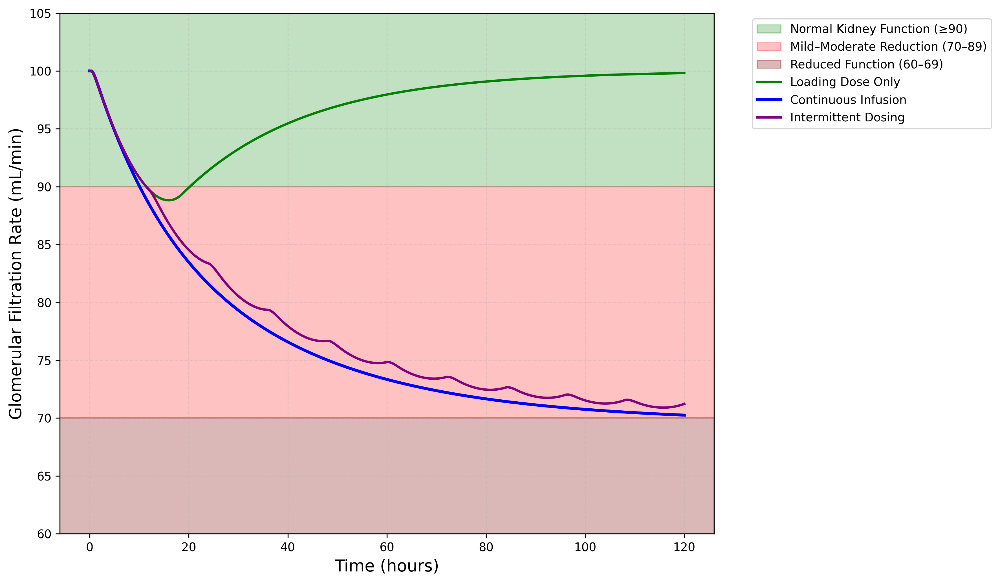

In [ ]:
# ====== GFR PLOT CELL (darker background zones) ======

plt.figure(figsize=(12, 7), dpi=300)

# --- Kidney Function Zones (3 segments) ---
# (bumped alphas into the 0.22–0.28 range so it’s darker but not heavy)
plt.axhspan(90, 105, color='green',  alpha=0.24, label='Normal Kidney Function (≥90)')
plt.axhspan(70, 90,  color='red',    alpha=0.24, label='Mild–Moderate Reduction (70–89)')
plt.axhspan(60, 70,  color='maroon', alpha=0.28, label='Reduced Function (60–69)')

# --- Plot Simulation Results ---
plt.plot(t, sol_load_res[:, 13], label="Loading Dose Only",   color='green',   lw=2)
plt.plot(t, sol_cont_res[:, 13], label="Continuous Infusion", color='blue',    lw=2.5)
plt.plot(t, sol_int_res[:, 13],  label="Intermittent Dosing", color='purple', lw=2)

# --- Formatting ---
#plt.title('GFR vs. Time in Response to Dosing Regimens', fontsize=16, fontweight='bold')
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Glomerular Filtration Rate (mL/min)', fontsize=14)

plt.ylim(60, 105)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

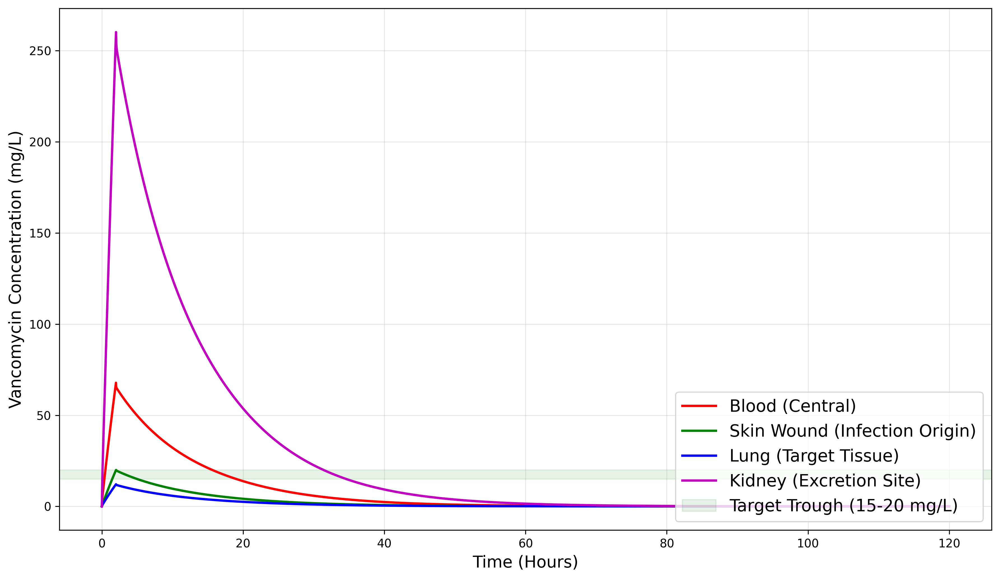

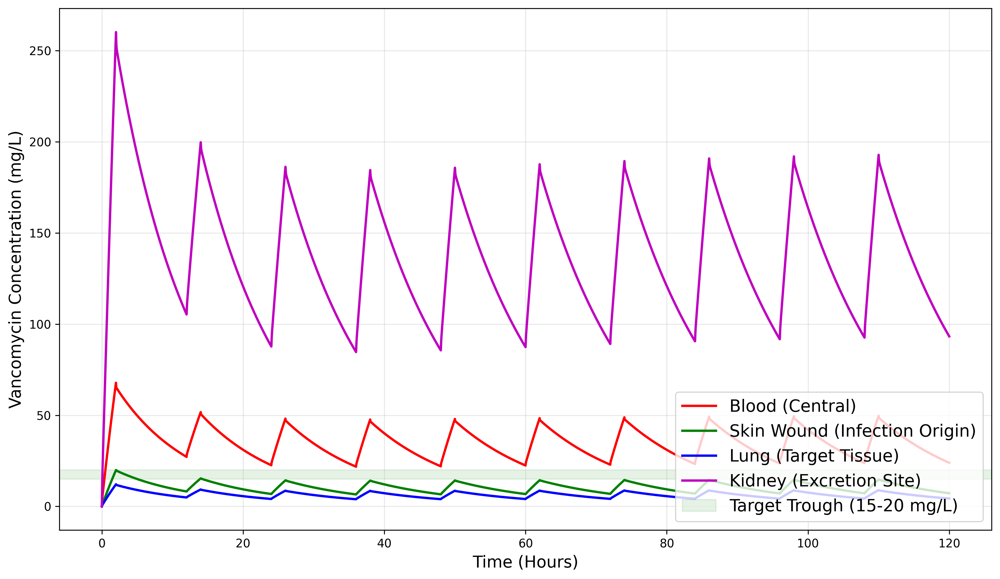

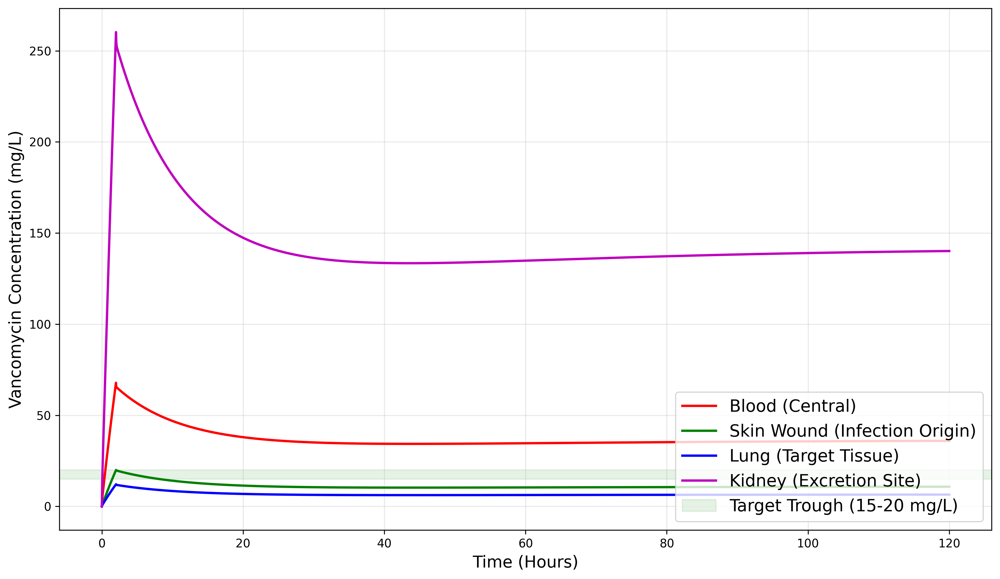

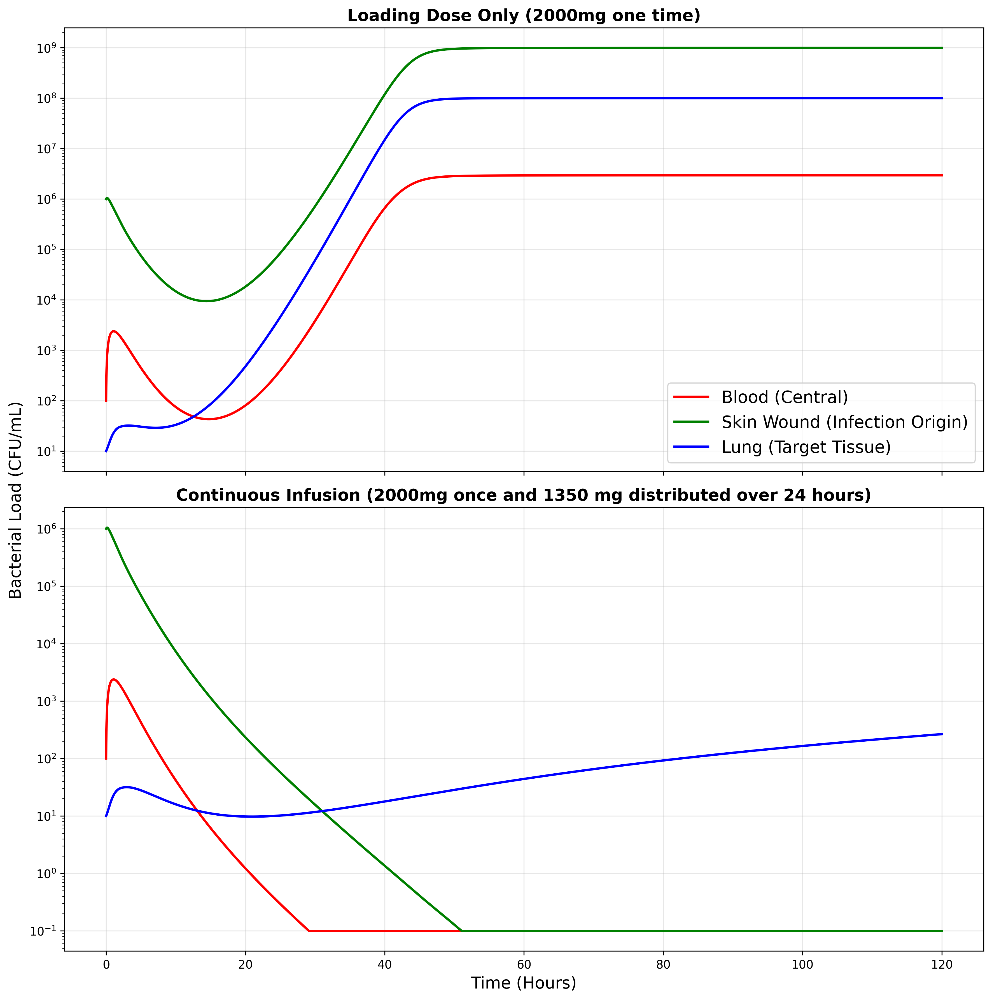

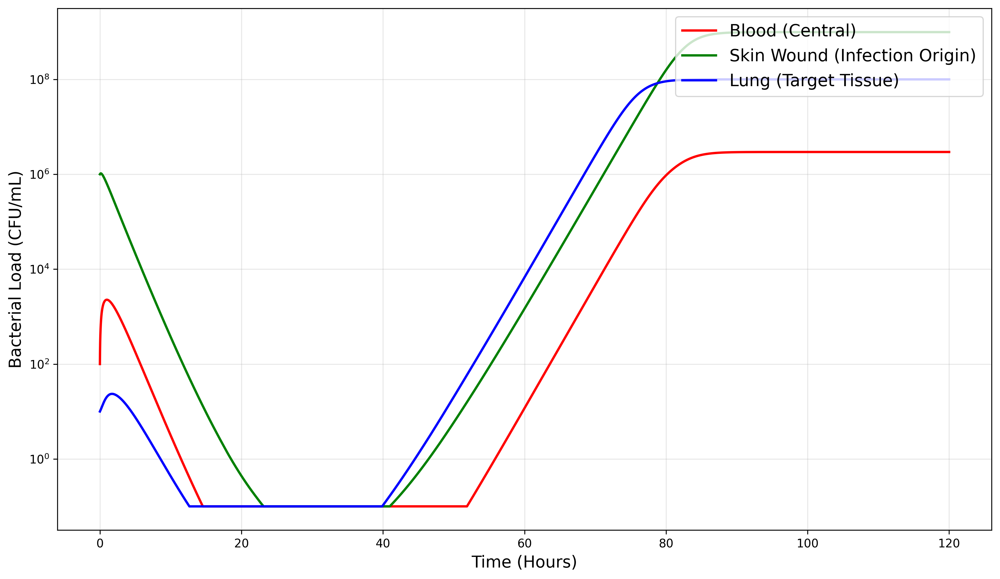

...

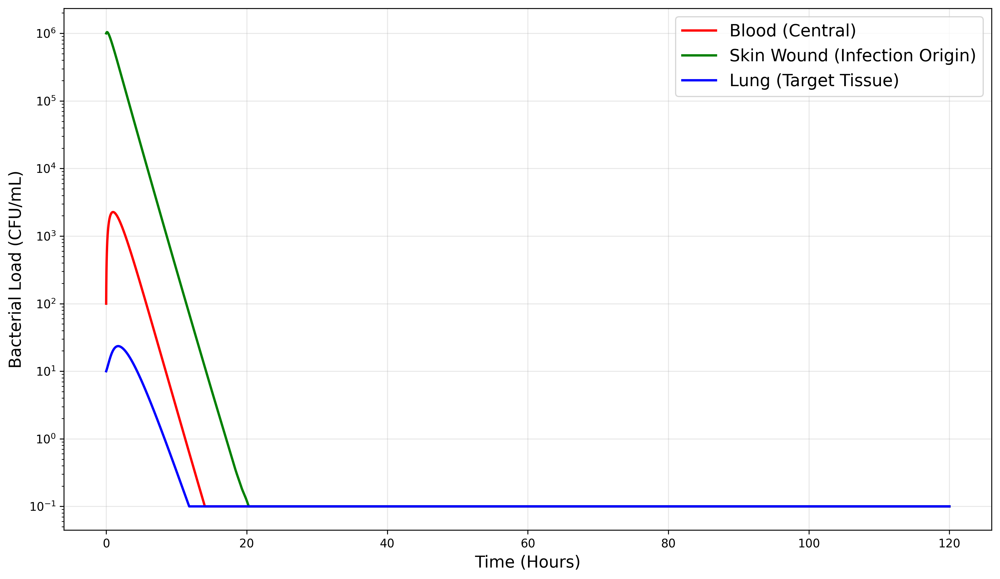

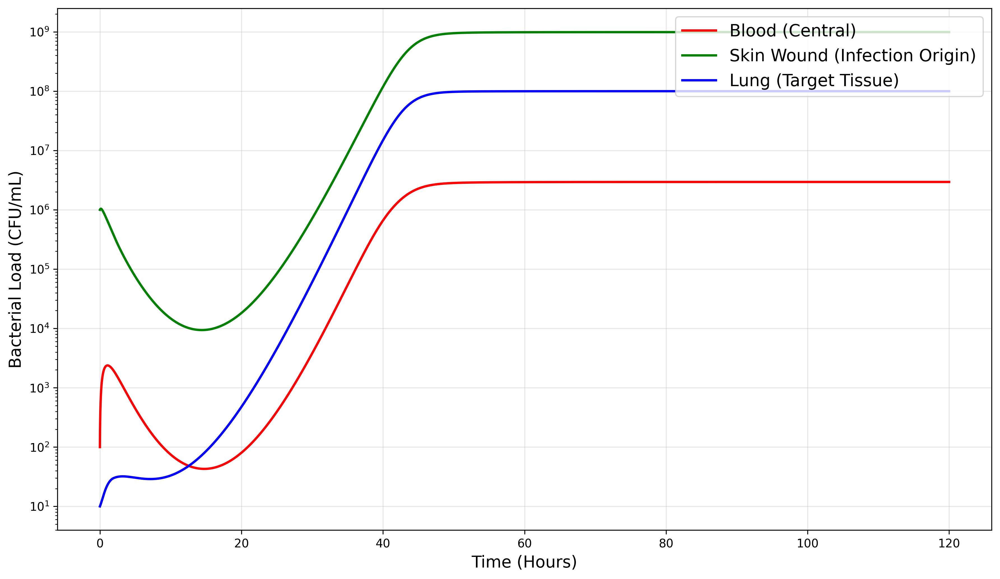

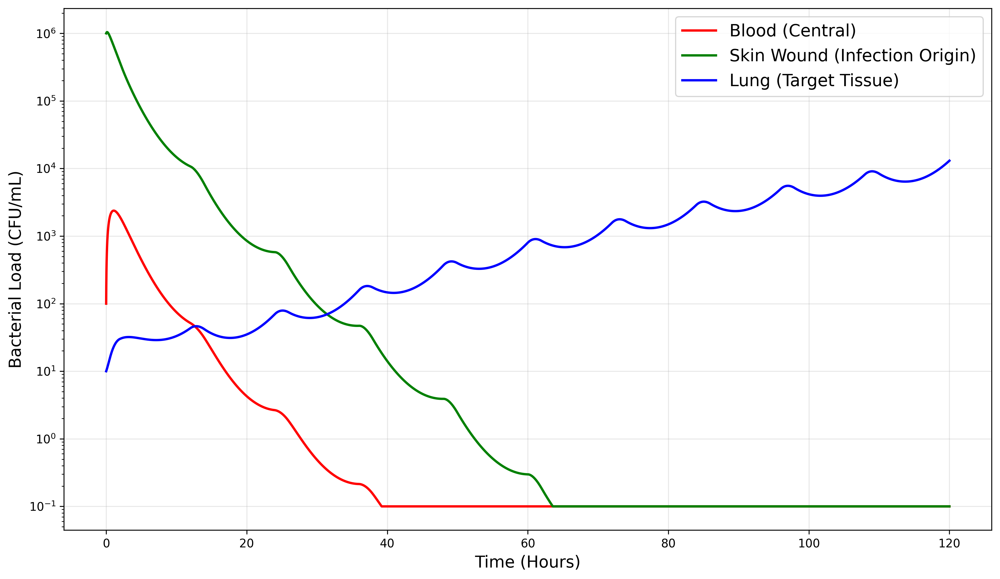

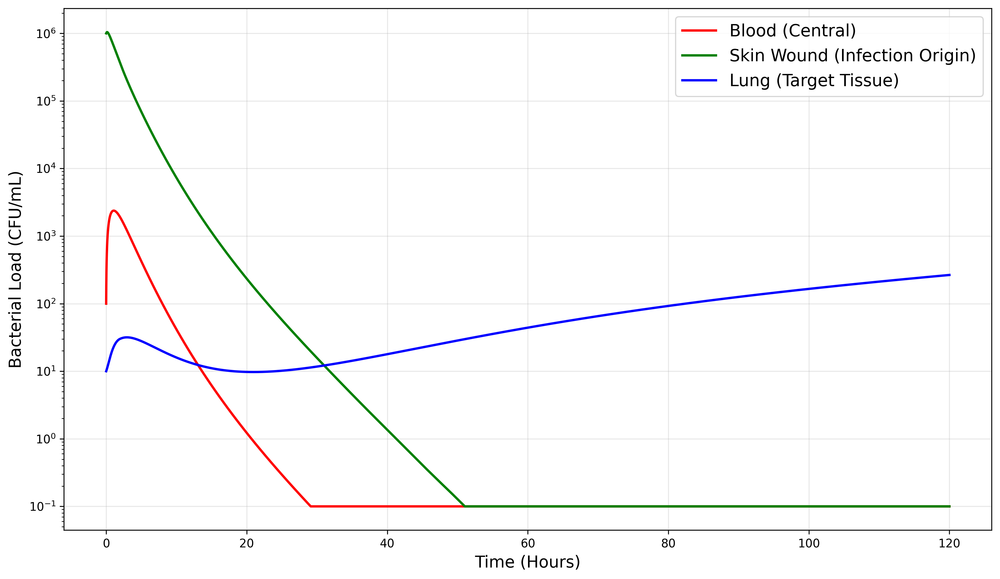

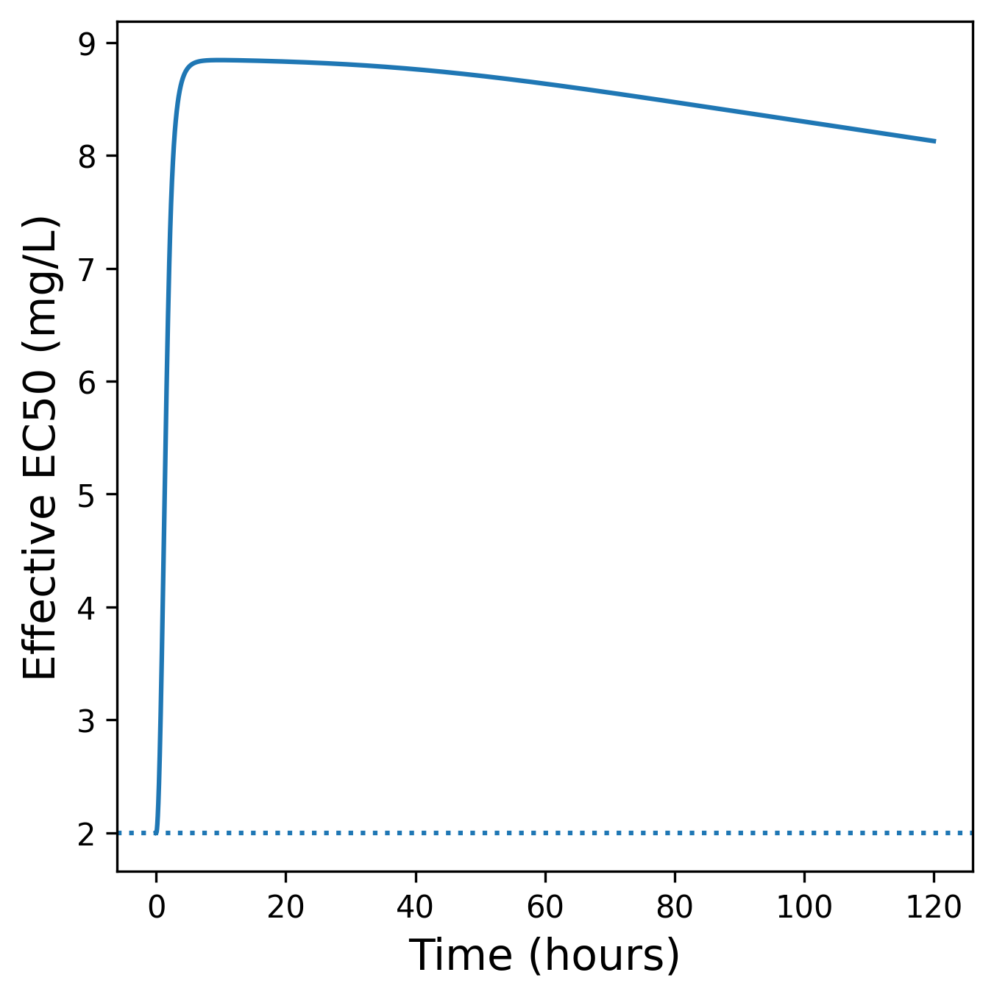

<Figure size 1500x1500 with 0 Axes>

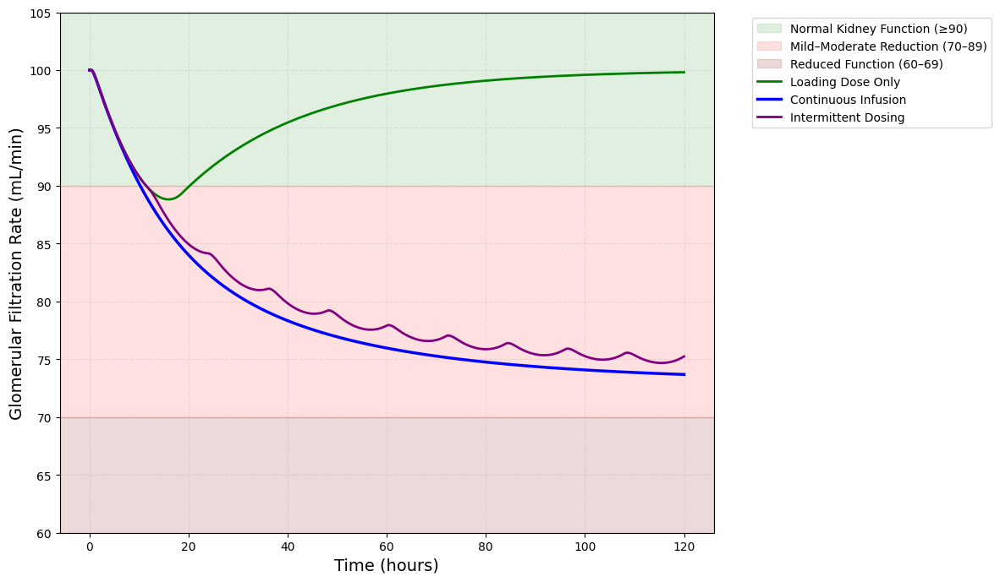

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

Vc = 5.3 # Central Volume (0.07 L/kg * 70kg): SHC
# kel = 0.104


def dose_loading_cons(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 0.0

  # 2) Continuous infusion: 1350 mg per 24h (15 mg/kg)
def dose_continuous_cons(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 1680.0 / 24.0  # mg/hr

  # 3) Intermittent dosing: 1350 mg over 2 hr every 12h (0–1, 12–13, 24–25, ...)
def dose_intermittent_cons(t):
    # Doses at 0, 12, 24, 36, 48, 60, 72 hours
    cycle_time = t % 12
    if t<=2:
        return 1000.0
    elif 0 <= cycle_time < 2:
        return 420.0  # 750mg/hr * 2hr = 1500mg
    return 0.0

def dose_loading(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 0.0

  # 2) Continuous infusion: 1350 mg per 24h (15 mg/kg)
def dose_continuous(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 2100.0 / 24.0  # mg/hr

  # 3) Intermittent dosing: 1350 mg over 2 hr every 12h (0–1, 12–13, 24–25, ...)
def dose_intermittent(t):
    # Doses at 0, 12, 24, 36, 48, 60, 72 hours
    cycle_time = t % 12
    if t<=2:
        return 1000.0
    elif 0 <= cycle_time < 2:
        return 525.0  # 750mg/hr * 2hr = 1500mg
    return 0.0

def vanco_mrsa_model(y,t,params,dose_fn):
  #PK related parameters
  input_term = dose_fn(t) / Vc
  Cb, Cs, Ck, Cl, P_wound, P_blood, P_lung, AR_on_wound, AR_off_wound, AR_on_blood, AR_off_blood, AR_on_lung, AR_off_lung, GFR, Crob, H_slow, H_fast = y
      #mass of drug in compartment (mg)
  V_skin, V_kidney, V_lung, V_rob = params['V'] #volume of compartments (L)
  Kp_skin, Kp_kidney, Kp_lung, Kp_rob = params['Kp'] #blood->peripheral compartment (1/hr)
  Q_skin, Q_kidney, Q_lung, Q_rob = params['Q'] #intercompartmental flow (L/hr)
  Kel_ref = params['Kel_ref'] #renal clearance
  GFR_ref = params['GFR_ref'] # mL/min, reference GFR
  GFR_baseline = params['GFR_baseline'] # mL/min, this patient's starting GFR
  C_tox = params['C_tox'] # mg/L, toxicity threshold
  C_tox_scale = params['C_tox_scale'] # mg/gfL, how sharply toxicity rises
  max_gfr_drop_frac = params['max_gfr_drop_frac'] # max 30% GFR reduction
  k_gfr_follow = params['k_gfr_follow'] # 1/hr, GFR response speed

  #mrsa related parameters
  r = params['r'] #mrsa growth rate (hr^(-1))
  K_w = params['K_wound'] #wound site carrying capacity (CFU/mL)
  K_b = params['K_blood'] #bloodstream carrying capacity (CFU/mL)
  K_l = params['K_lung'] #lung carrying capacity (CFU/mL)
  Emax = params['Emax'] #maximum kill rate (hr^(-1))
  EC50_0 = params['EC50_0'] #drug concentration at 50% Emax, no resistance (mg/L)
  Slp_AR = params['Slp_AR'] #resistance strength coefficient [UNITS]
  k_on = params['k_on'] #rate constant for susceptible -> resistant change
  k_off = params.get('k_off', 0.00139) #rate constant for resistant -> susceptible change, using .get for safety
  gamma = params['gamma'] #Hill coefficient
  s = params['s'] #wound to blood dissemination (hr^(-1))
  l = params['l'] #blood to lung dissemination (hr^(-1))
  d = params['d'] #immune clearance of bloodstream bacteria (hr^(-1))

  Kel = params['Kel_ref'] * (GFR / params['GFR_ref'])
  #infusion
  # infusion_rate = 0.0
  # if 0 <= t <= 2:
  #   infusion_rate = 625.0 #loading - 1250 mg over 2 hr
  # elif t >= 12 and (t%12) <= 2:
  #   infusion_rate = 500.0 #maintenance - 1000 mg over 2 hr

  # 1) Loading dose: 2000 mg over 1 hour (20-25 mg/kg with max at 2000)


  # C_blood = A_blood / V_blood
  # C_skin = A_skin / V_skin
  # C_kidney = A_kidney / V_kidney
  # C_lung = A_lung / V_lung

  # P_wound = max(y[4], 0.0)
  # P_blood = max(y[5], 0.0)
  # P_lung  = max(y[6], 0.0)

  Cv_skin = Cs / Kp_skin
  Cv_kidney = Ck / Kp_kidney
  Cv_lung = Cl / Kp_lung
  Cv_rob = Crob / Kp_rob

  # dCb_dt = (
  #       -Kel * Cb
  #       - Kp_kidney * (Cb - Ck)
  #       - Kp_lung * (Cb - Cl)
  #       - Kp_skin * (Cb - Cs)
  #       + input_term
  #   )

  # dCs_dt = Kp_skin * (Cb - Cs)
  # dCk_dt = Kp_kidney * (Cb - Ck)
  # dCl_dt = Kp_lung * (Cb - Cl)

  dCb_dt = (1.0 / Vc) * (
        Q_skin * (Cv_skin - Cb)
        + Q_kidney * (Cv_kidney - Cb)
        + Q_lung * (Cv_lung - Cb)
        + Q_rob * (Cv_rob - Cb)
      ) + input_term


  dCs_dt = (Q_skin / V_skin) * (Cb - Cv_skin)
  #CLrenal = params['Kel_ref'] * Vc * (GFR / params['GFR_ref'])
  CLrenal = 2.7 * (GFR/GFR_ref)
  dCk_dt = (Q_kidney / V_kidney) * (Cb - Cv_kidney) - (CLrenal / V_kidney) * Cv_kidney
  dCl_dt = (Q_lung / V_lung) * (Cb - Cv_lung)
  dCrob = (Q_rob / V_rob) * (Cb - Cv_rob)


  # dA_blood = (infusion_rate + Q_skin * (C_skin / Kp_skin)
  #             + Q_kidney * (C_kidney / Kp_kidney)
  #             + Q_lung * (C_lung / Kp_lung)
  #             - (Q_skin + Q_kidney + Q_lung) * C_blood)

  # dA_skin = Q_skin * (C_blood - C_skin / Kp_skin)
  # dA_kidney = Q_kidney * (C_blood - C_kidney / Kp_kidney) - Kel * C_kidney
  # dA_lung = Q_lung * (C_blood - C_lung / Kp_lung)

  dAR_off_wound = -k_on * Cs * AR_off_wound + k_off * AR_on_wound
  dAR_on_wound = k_on * Cs * AR_off_wound - k_off * AR_on_wound
  dAR_off_blood = -k_on * Cb * AR_off_blood + k_off * AR_on_blood
  dAR_on_blood = k_on * Cb * AR_off_blood - k_off * AR_on_blood
  dAR_off_lung = -k_on * Cl * AR_off_lung + k_off * AR_on_lung
  dAR_on_lung = k_on * Cl * AR_off_lung - k_off * AR_on_lung

  def emax_kill(C, AR_on_local, AR_off_local):
    AR_eff = 1 + Slp_AR * AR_on_local
    EC50 = EC50_0 * AR_eff
    if C> 0:
      return (Emax * C**gamma) / (EC50**gamma + C**gamma)
    return 0.0

  dP_wound = (r * P_wound * (1.0 - P_wound / K_w) -
              emax_kill(Cs, AR_on_wound, AR_off_wound) * P_wound - s * P_wound)

  dP_blood = (r * P_blood * (1.0 - P_blood / K_b) - emax_kill(Cb, AR_on_wound, AR_off_wound) * P_blood
              - d * P_blood + s * P_wound - l * P_blood)

  dP_lung = (r * P_lung * (1.0 - P_lung / K_l) -
             emax_kill(Cl, AR_on_lung, AR_off_lung) * P_lung + l * P_blood)


  # if y[4] <= 0.0:
  #       dP_wound = max(dP_wound, 0.0)
  # if y[5] <= 0.0:
  #       dP_blood = max(dP_blood, 0.0)
  # if y[6] <= 0.0:
  #       dP_lung = max(dP_lung, 0.0)

  toxic_drive = max(Ck - params['C_tox'], 0.0)
  tox_signal = toxic_drive / (params['C_tox_scale'] + toxic_drive)
  gfr_target = params['GFR_baseline'] * (1.0 - params['max_gfr_drop_frac'] * tox_signal)
  dGFR_dt = params['k_gfr_follow'] * (gfr_target - GFR)

  R_ghr = dose_fn(t) / 1000.0
  hist_input = 2.486 * (R_ghr ** 1.33) if R_ghr > 0 else 0.0
  k_hist_decay = 2.4 #(1/hr)
  k_hist_rise  = 12.0 #(1/hr)
  dH_slow = -k_hist_decay * H_slow + hist_input
  dH_fast = -k_hist_rise  * H_fast + hist_input



  return [dCb_dt, dCs_dt, dCk_dt, dCl_dt, dP_wound, dP_blood, dP_lung, dAR_on_wound,
      dAR_off_wound, dAR_on_blood, dAR_off_blood, dAR_on_lung, dAR_off_lung, dGFR_dt, dCrob, dH_slow, dH_fast]

params = {
      'V':  [3.3, 0.31, 0.50,40.0],
      'Q':  [19.5, 74.0, 5.0,230.0],
      'Kp': [0.30, 4.0, 0.18,0.5],
      'Kel_ref': 0.104,
      'GFR_ref': 100.0,
      'GFR_baseline': 100.0,
      'C_tox': 60.0,
      'C_tox_scale': 40.0,
      'max_gfr_drop_frac': 0.40,
      'k_gfr_follow': 0.04,
      'r': 0.6,
      'K_wound': 1e9,
      'K_blood': 1e6,
      'K_lung': 1e8,
      'Emax': 1.5,
      'EC50_0': 2.0,
      'Slp_AR': 3.43,
      'k_on': 0.0635,
      'k_off': 0.00139, # Re-added k_off
      'gamma': 1.5,
      's': 0.005,
      'l': 0.01,
      'd': 0.5,
  }

params_no_resist = {**params, 'k_on': 0.0, 'Slp_AR': 0.0, 'k_off':0.0} # Ensure k_off is set for no resistance if desired
params_resist = params
P0_wound = 1e6
P0_blood = 1e2
P0_lungs = 1e1

atol = [
    1e-6, 1e-6, 1e-6, 1e-6, 1e-1, 1e-1, 1e-1, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8,0.001,1e-6,1e-6,1e-6,
]

y0 = [0, 0, 0, 0, P0_wound, P0_blood, P0_lungs, 0, 1,0,1,0,1,100,0, 0, 0]
t = np.linspace(0, 120, 50000)

sol_load_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_loading_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_continuous_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_nores_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_intermittent_cons,), mxstep=10000,atol=atol, rtol=1e-6)

sol_load_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_loading_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_continuous_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_res_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_intermittent_cons,), mxstep=10000,atol=atol, rtol=1e-6)

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Loading Dose Only (2000 mg over 2 hours)", fontsize=14,fontweight='bold')
solutions = [sol_load_res_cons]
plt.plot(t, sol_load_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t, sol_load_res_cons[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_load_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t, sol_load_res_cons[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Intermittent Dosing (1050mg every 12 hours)", fontsize=14,fontweight='bold')
solutions = [sol_int_res_cons]
plt.plot(t, sol_int_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_int_res_cons[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_int_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_int_res_cons[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Continuous Infusion (2100mg over 24 hours)", fontsize=14,fontweight='bold')
plt.plot(t, sol_cont_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_cont_res_cons[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_cont_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_cont_res_cons[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, dpi = 300)
#titles = ["Loading Dose Only (2000mg one time)", "Continuous Infusion (2000mg once and 1350 mg distributed over 24 hours)"]#, "Intermittent Dosing (1350mg q12h)"]
solutions = [sol_load_res_cons, sol_cont_res_cons]#, sol_int_res]
fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)

for ax, sol, title in zip(axes, solutions, titles):
    ax.semilogy(t, np.maximum(sol[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
    ax.semilogy(t,np.maximum(sol[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
    ax.semilogy(t, np.maximum(sol[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
    #ax.plot(t,sol[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.set_ylabel("Vancomycin Concentration (mg/L)")
    # Therapeutic Window for MRSA
    #ax.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
    #ax.axhline(y=10, color='gray', linestyle=':', label="MIC for MRSA (approx)")
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Time (Hours)",fontsize=14)
axes[0].legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Loading Dose Only", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_load_nores_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Intermittent Dosing", fontsize=14,fontweight='bold')
solutions = [sol_int_nores_cons]
#fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_int_nores_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Continuous Infusion", fontsize=14,fontweight='bold')
#fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_cont_nores_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Loading Dose Only", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_load_res_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Intermittent Dosing", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_int_res_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Continuous Infusion", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_cont_res_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

AR_on = sol_load_res_cons[:, 7]
EC50_effective = params['EC50_0'] * (1 + params['Slp_AR'] * AR_on)
plt.figure(figsize=(5,5),dpi=300)
plt.plot(t, EC50_effective, label="Effective EC50")
plt.axhline(y=params['EC50_0'], ls=':', label="Baseline EC50")
#plt.title("Resistance Emergence", fontsize=14,fontweight='bold')
plt.ylabel("Effective EC50 (mg/L)",fontsize=14)
plt.xlabel("Time (hours)",fontsize=14)

plt.figure(figsize=(5,5), dpi=300)

plt.figure(figsize=(12, 7))

# --- Kidney Function Zones (3 segments) ---
plt.axhspan(90, 105, color='green',  alpha=0.12, label='Normal Kidney Function (≥90)')
plt.axhspan(70, 90,  color='red', alpha=0.12, label='Mild–Moderate Reduction (70–89)')
plt.axhspan(60, 70,  color='maroon',    alpha=0.15, label='Reduced Function (60–69)')

# --- Plot Your Simulation Results ---
plt.plot(t, sol_load_res_cons[:, 13], label="Loading Dose Only",   color='green',   lw=2)
plt.plot(t, sol_cont_res_cons[:, 13], label="Continuous Infusion", color='blue',    lw=2.5)
plt.plot(t, sol_int_res_cons[:, 13],  label="Intermittent Dosing", color='purple', lw=2)

# --- Formatting ---
#plt.title('GFR vs. Time in Response to Dosing Regimens', fontsize=16, fontweight='bold')
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Glomerular Filtration Rate (mL/min)', fontsize=14)

plt.ylim(60, 105)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

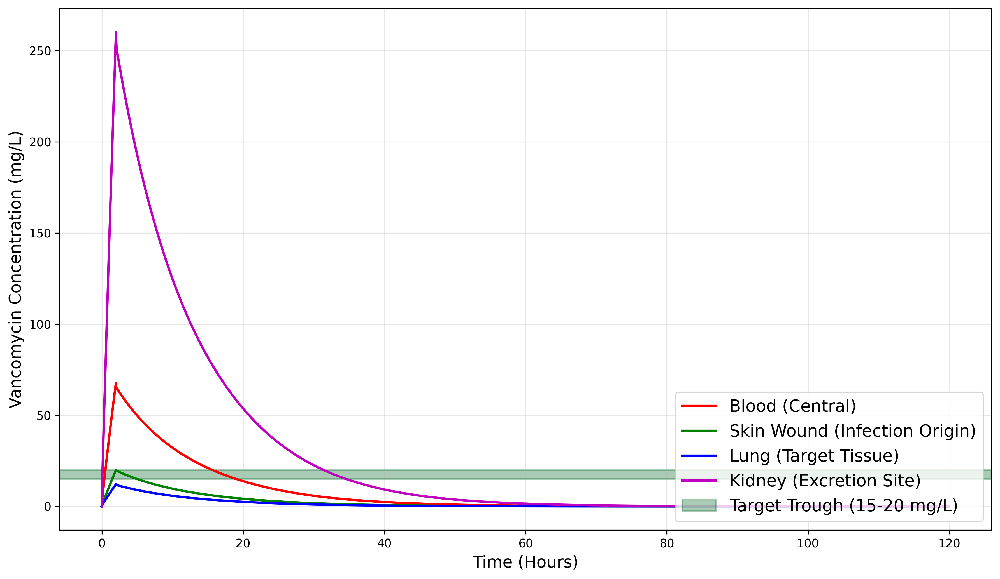

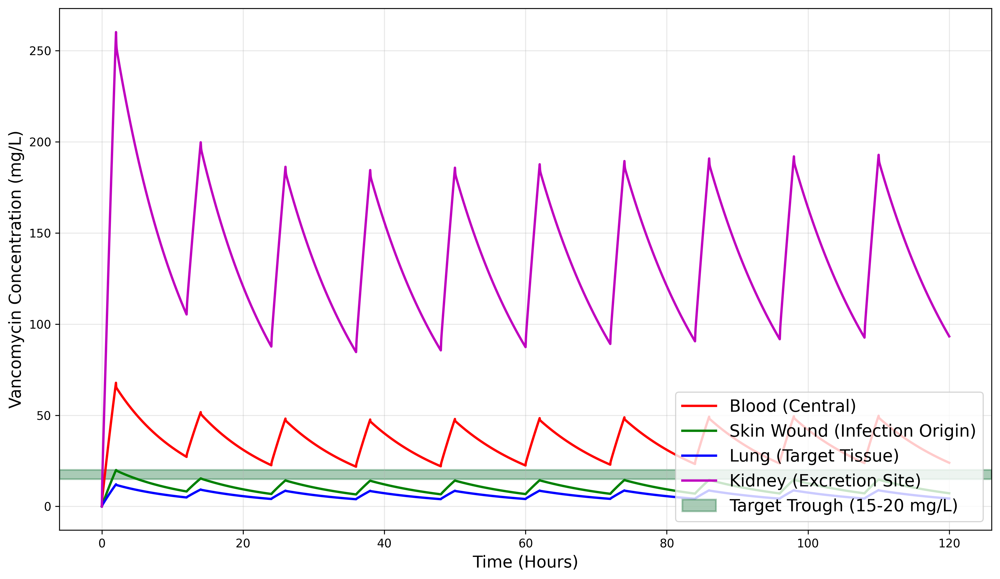

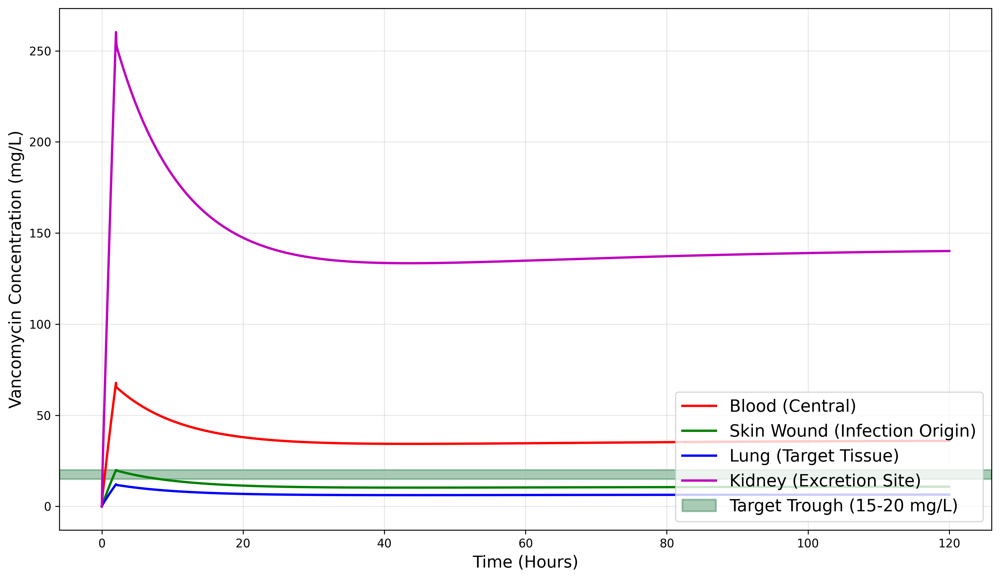

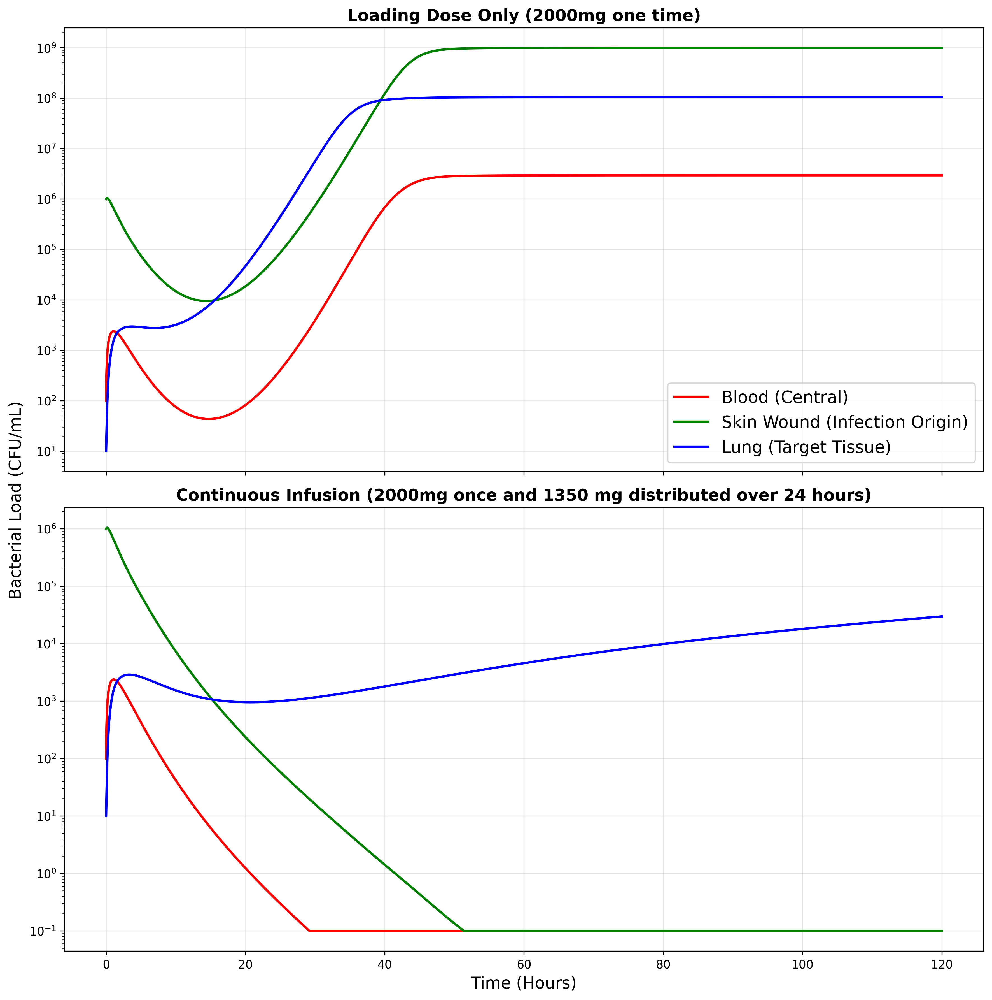

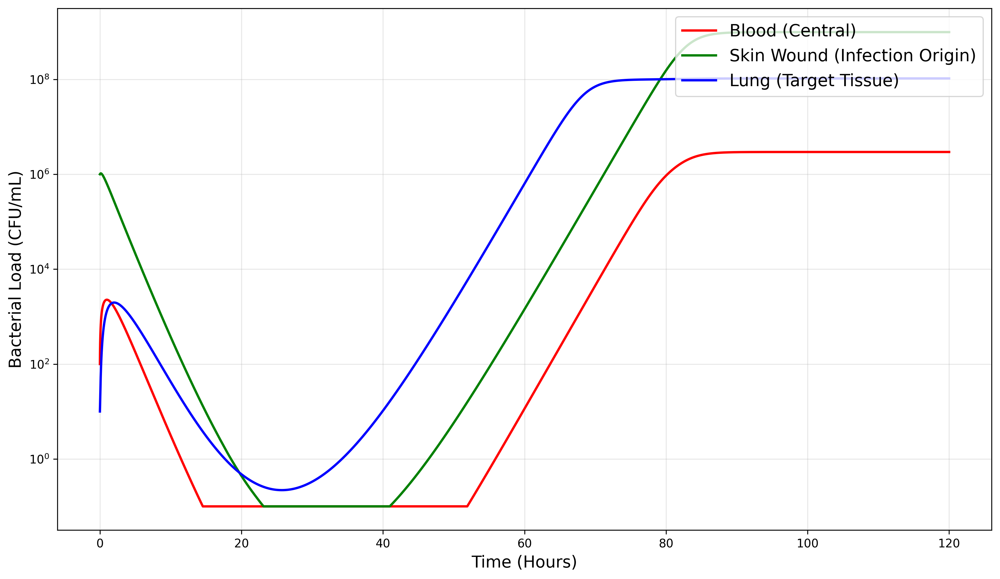

...

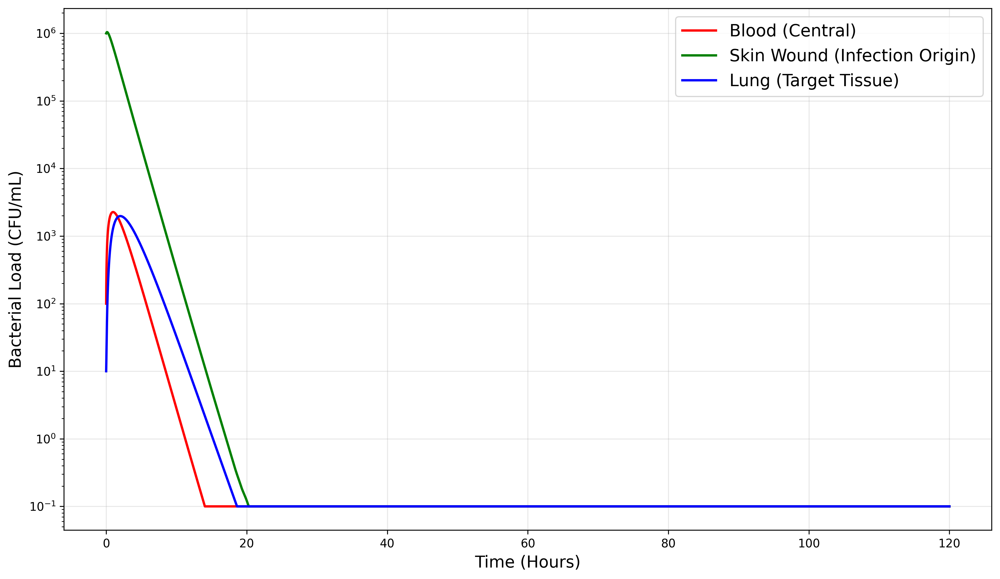

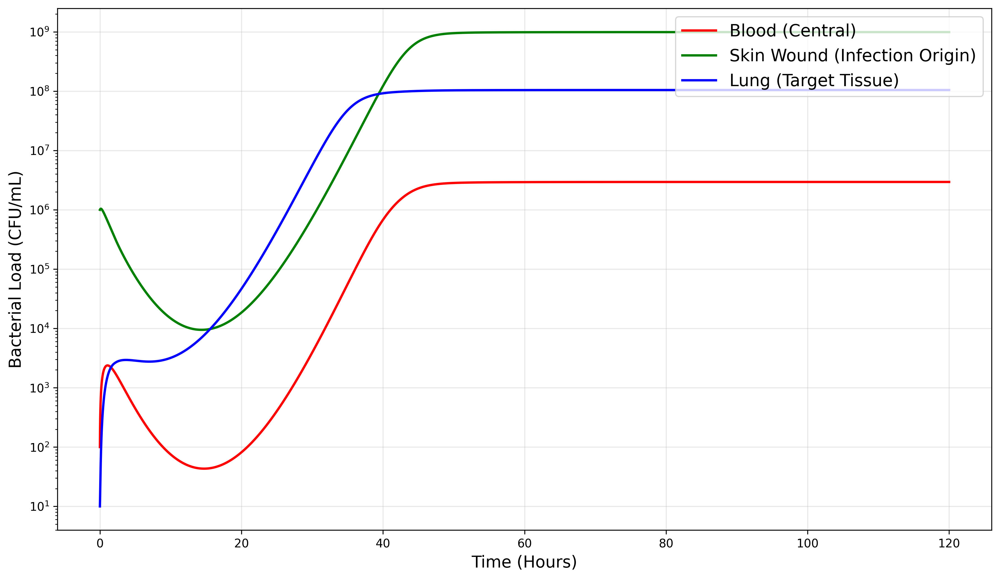

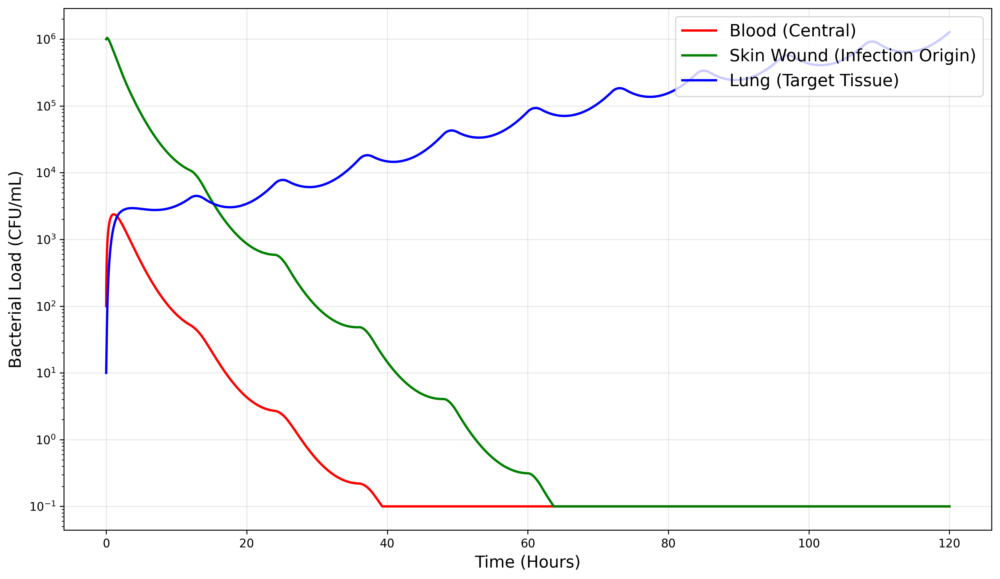

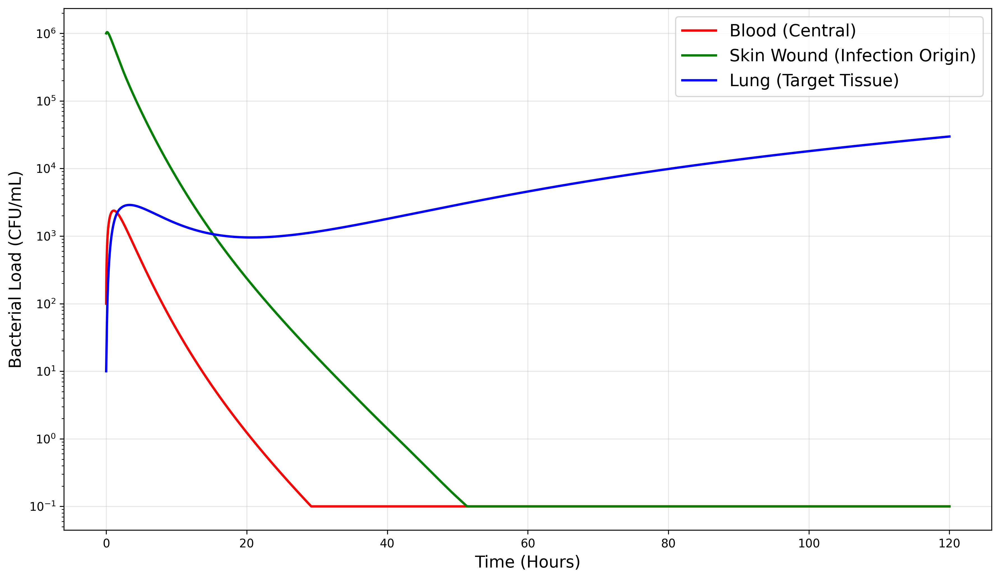

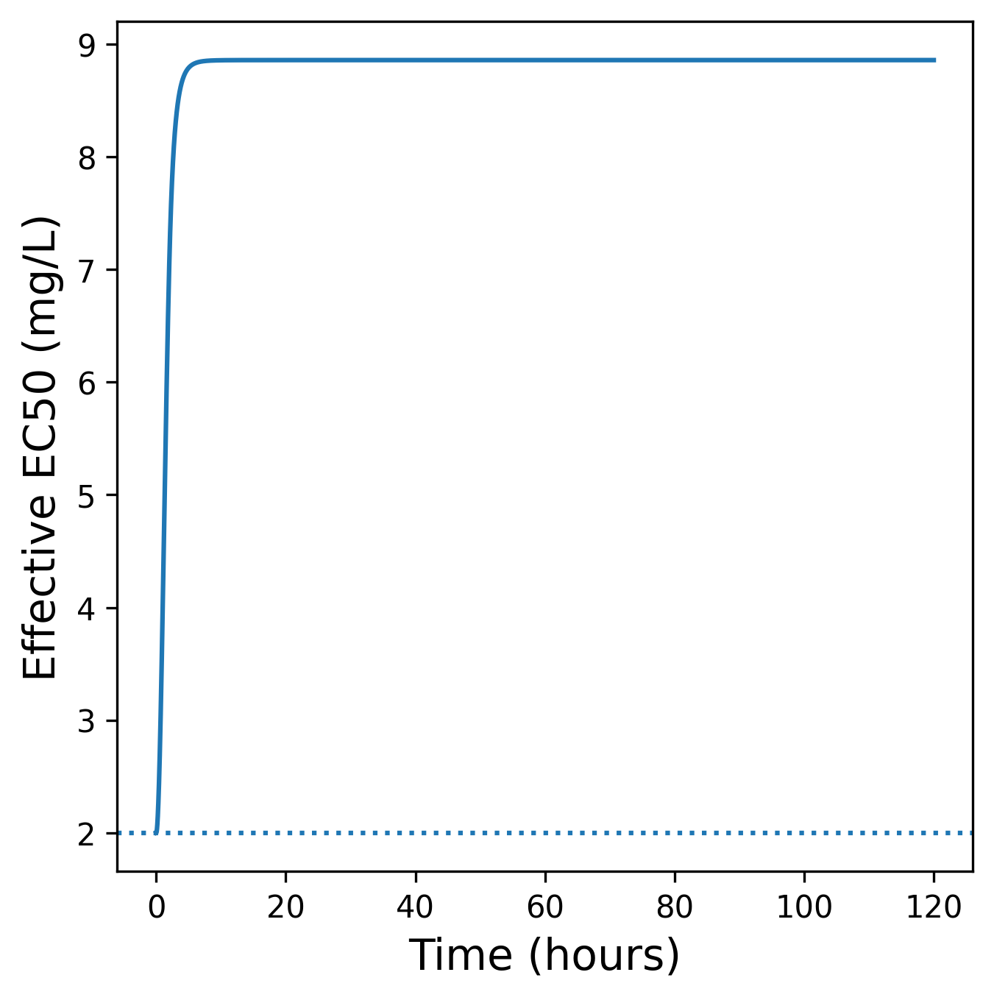

<Figure size 1500x1500 with 0 Axes>

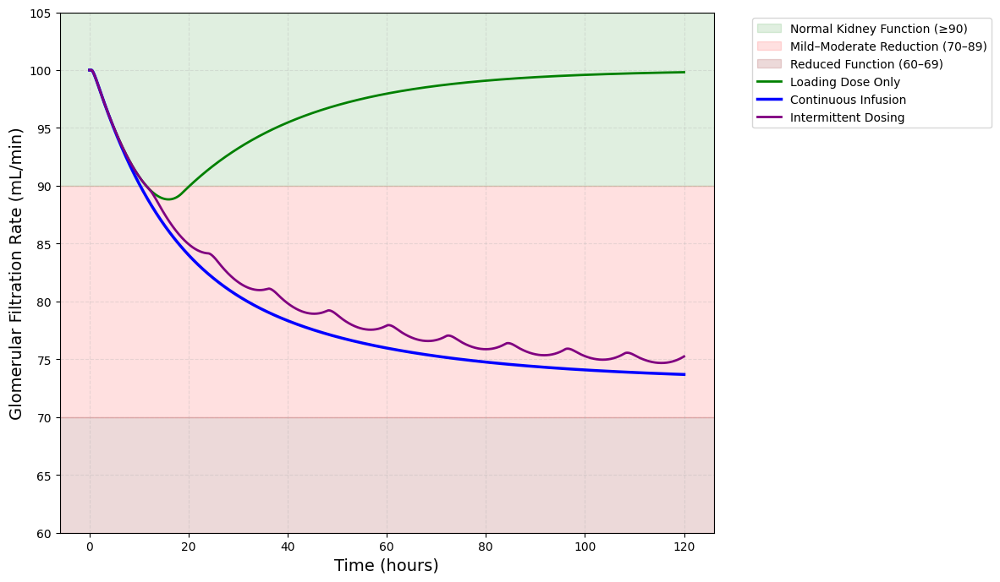

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

Vc = 5.3


def dose_loading_cons(t):
    if 0 <= t < 2:
        return 1000.0
    return 0.0


def dose_continuous_cons(t):
    if 0 <= t < 2:
        return 1000.0
    return 1680.0 / 24.0


def dose_intermittent_cons(t):
    cycle_time = t % 12
    if t <= 2:
        return 1000.0
    elif 0 <= cycle_time < 2:
        return 420.0
    return 0.0


def dose_loading(t):
    if 0 <= t < 2:
        return 1000.0
    return 0.0


def dose_continuous(t):
    if 0 <= t < 2:
        return 1000.0
    return 2100.0 / 24.0


def dose_intermittent(t):
    cycle_time = t % 12
    if t <= 2:
        return 1000.0
    elif 0 <= cycle_time < 2:
        return 525.0
    return 0.0


def vanco_mrsa_model(y, t, params, dose_fn):
    input_term = dose_fn(t) / Vc
    Cb, Cs, Ck, Cl, P_wound, P_blood, P_lung, AR_on_wound, AR_off_wound, AR_on_blood, AR_off_blood, AR_on_lung, AR_off_lung, GFR, Crob, H_slow, H_fast = y
    V_skin, V_kidney, V_lung, V_rob = params['V']
    Kp_skin, Kp_kidney, Kp_lung, Kp_rob = params['Kp']
    Q_skin, Q_kidney, Q_lung, Q_rob = params['Q']
    Kel_ref = params['Kel_ref']
    GFR_ref = params['GFR_ref']
    GFR_baseline = params['GFR_baseline']
    C_tox = params['C_tox']
    C_tox_scale = params['C_tox_scale']
    max_gfr_drop_frac = params['max_gfr_drop_frac']
    k_gfr_follow = params['k_gfr_follow']

    r = params['r']
    K_w = params['K_wound']
    K_b = params['K_blood']
    K_l = params['K_lung']
    Emax = params['Emax']
    EC50_0 = params['EC50_0']
    Slp_AR = params['Slp_AR']
    k_on = params['k_on']
    gamma = params['gamma']
    s = params['s']
    l = params['l']
    d = params['d']

    Kel = params['Kel_ref'] * (GFR / params['GFR_ref'])

    Cv_skin = Cs / Kp_skin
    Cv_kidney = Ck / Kp_kidney
    Cv_lung = Cl / Kp_lung
    Cv_rob = Crob / Kp_rob

    dCb_dt = (1.0 / Vc) * (
        Q_skin * (Cv_skin - Cb)
        + Q_kidney * (Cv_kidney - Cb)
        + Q_lung * (Cv_lung - Cb)
        + Q_rob * (Cv_rob - Cb)
    ) + input_term

    dCs_dt = (Q_skin / V_skin) * (Cb - Cv_skin)
    CLrenal = 2.7 * (GFR / GFR_ref)
    dCk_dt = (Q_kidney / V_kidney) * (Cb - Cv_kidney) - (CLrenal / V_kidney) * Cv_kidney
    dCl_dt = (Q_lung / V_lung) * (Cb - Cv_lung)
    dCrob = (Q_rob / V_rob) * (Cb - Cv_rob)

    dAR_off_wound = -k_on * Cs * AR_off_wound
    dAR_on_wound = k_on * Cs * AR_off_wound
    dAR_off_blood = -k_on * Cb * AR_off_blood
    dAR_on_blood = k_on * Cb * AR_off_blood
    dAR_off_lung = -k_on * Cl * AR_off_lung
    dAR_on_lung = k_on * Cl * AR_off_lung

    def emax_kill(C, AR_on_local, AR_off_local):
        AR_eff = 1 + Slp_AR * AR_on_local
        EC50 = EC50_0 * AR_eff
        if C > 0:
            return (Emax * C**gamma) / (EC50**gamma + C**gamma)
        return 0.0

    dP_wound = (r * P_wound * (1.0 - P_wound / K_w) -
                emax_kill(Cs, AR_on_wound, AR_off_wound) * P_wound - s * P_wound)

    dP_blood = (r * P_blood * (1.0 - P_blood / K_b) - emax_kill(Cb, AR_on_wound, AR_off_wound) * P_blood
                - d * P_blood + s * P_wound - l * P_blood)

    dP_lung = (r * P_lung * (1.0 - P_lung / K_l) -
               emax_kill(Cl, AR_on_lung, AR_off_lung) * P_lung + P_blood)

    toxic_drive = max(Ck - params['C_tox'], 0.0)
    tox_signal = toxic_drive / (params['C_tox_scale'] + toxic_drive)
    gfr_target = params['GFR_baseline'] * (1.0 - params['max_gfr_drop_frac'] * tox_signal)
    dGFR_dt = params['k_gfr_follow'] * (gfr_target - GFR)

    R_ghr = dose_fn(t) / 1000.0
    hist_input = 2.486 * (R_ghr ** 1.33) if R_ghr > 0 else 0.0
    k_hist_decay = 2.4
    k_hist_rise = 12.0
    dH_slow = -k_hist_decay * H_slow + hist_input
    dH_fast = -k_hist_rise * H_fast + hist_input

    return [dCb_dt, dCs_dt, dCk_dt, dCl_dt, dP_wound, dP_blood, dP_lung, dAR_on_wound,
            dAR_off_wound, dAR_on_blood, dAR_off_blood, dAR_on_lung, dAR_off_lung, dGFR_dt, dCrob, dH_slow, dH_fast]


params = {
    'V':  [3.3, 0.31, 0.50, 40.0],
    'Q':  [19.5, 74.0, 5.0, 230.0],
    'Kp': [0.30, 4.0, 0.18, 0.5],
    'Kel_ref': 0.104,
    'GFR_ref': 100.0,
    'GFR_baseline': 100.0,
    'C_tox': 60.0,
    'C_tox_scale': 40.0,
    'max_gfr_drop_frac': 0.40,
    'k_gfr_follow': 0.04,
    'r': 0.6,
    'K_wound': 1e9,
    'K_blood': 1e6,
    'K_lung': 1e8,
    'Emax': 1.5,
    'EC50_0': 2.0,
    'Slp_AR': 3.43,
    'k_on': 0.0635,
    'gamma': 1.5,
    's': 0.005,
    'l': 0.01,
    'd': 0.5,
}

params_no_resist = {**params, 'k_on': 0.0, 'Slp_AR': 0.0}
params_resist = params
P0_wound = 1e6
P0_blood = 1e2
P0_lungs = 1e1

atol = [
    1e-6, 1e-6, 1e-6, 1e-6, 1e-1, 1e-1, 1e-1, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 0.001, 1e-6, 1e-6, 1e-6,
]

y0 = [0, 0, 0, 0, P0_wound, P0_blood, P0_lungs, 0, 1, 0, 1, 0, 1, 100, 0, 0, 0]
t = np.linspace(0, 120, 50000)

sol_load_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_loading_cons,), mxstep=10000, atol=atol, rtol=1e-6)
sol_cont_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_continuous_cons,), mxstep=10000, atol=atol, rtol=1e-6)
sol_int_nores_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_intermittent_cons,), mxstep=10000, atol=atol, rtol=1e-6)

sol_load_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_loading_cons,), mxstep=10000, atol=atol, rtol=1e-6)
sol_cont_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_continuous_cons,), mxstep=10000, atol=atol, rtol=1e-6)
sol_int_res_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_intermittent_cons,), mxstep=10000, atol=atol, rtol=1e-6)

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Loading Dose Only (2000 mg over 2 hours)", fontsize=14, fontweight='bold')
solutions = [sol_load_res_cons]
plt.plot(t, sol_load_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t, sol_load_res_cons[:, 1], 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.plot(t, sol_load_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t, sol_load_res_cons[:, 2], 'm-', linewidth=2, label="Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)", fontsize=14)
plt.axhspan(15, 20, facecolor="#0B6B2E", alpha=0.35, edgecolor="#0B6B2E", linewidth=1.5, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='lower right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Intermittent Dosing (1050mg every 12 hours)", fontsize=14, fontweight='bold')
solutions = [sol_int_res_cons]
plt.plot(t, sol_int_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t, sol_int_res_cons[:, 1], 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.plot(t, sol_int_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t, sol_int_res_cons[:, 2], 'm-', linewidth=2, label="Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)", fontsize=14)
plt.axhspan(15, 20, facecolor="#0B6B2E", alpha=0.35, edgecolor="#0B6B2E", linewidth=1.5, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='lower right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Continuous Infusion (2100mg over 24 hours)", fontsize=14, fontweight='bold')
plt.plot(t, sol_cont_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t, sol_cont_res_cons[:, 1], 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.plot(t, sol_cont_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t, sol_cont_res_cons[:, 2], 'm-', linewidth=2, label="Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)", fontsize=14)
plt.axhspan(15, 20, facecolor="#0B6B2E", alpha=0.35, edgecolor="#0B6B2E", linewidth=1.5, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='lower right', fontsize='x-large')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, dpi=300)
#titles = ["Loading Dose Only (2000mg one time)", "Continuous Infusion (2000mg once and 1350 mg distributed over 24 hours)"]
solutions = [sol_load_res_cons, sol_cont_res_cons]
fig.supylabel("Bacterial Load (CFU/mL)", fontsize=14)

for ax, sol, title in zip(axes, solutions, titles):
    ax.semilogy(t, np.maximum(sol[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
    ax.semilogy(t, np.maximum(sol[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
    ax.semilogy(t, np.maximum(sol[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Time (Hours)", fontsize=14)
axes[0].legend(loc='lower right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Loading Dose Only", fontsize=14, fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.ylabel("Bacterial Load (CFU/mL)", fontsize=14)
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='upper right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Intermittent Dosing", fontsize=14, fontweight='bold')
solutions = [sol_int_nores_cons]
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.ylabel("Bacterial Load (CFU/mL)", fontsize=14)
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='upper right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Susceptible MRSA: Continuous Infusion", fontsize=14, fontweight='bold')
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.ylabel("Bacterial Load (CFU/mL)", fontsize=14)
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='upper right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Loading Dose Only", fontsize=14, fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.ylabel("Bacterial Load (CFU/mL)", fontsize=14)
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='upper right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
##plt.title("Resistant MRSA: Intermittent Dosing", fontsize=14, fontweight='bold')
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.ylabel("Bacterial Load (CFU/mL)", fontsize=14)
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='upper right', fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
#plt.title("Resistant MRSA: Continuous Infusion", fontsize=14, fontweight='bold')
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 5], 1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 4], 1e-1), 'g-', linewidth=2, label="Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 6], 1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.ylabel("Bacterial Load (CFU/mL)", fontsize=14)
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)", fontsize=14)
plt.legend(loc='upper right', fontsize='x-large')
plt.tight_layout()
plt.show()

AR_on = sol_load_res_cons[:, 7]
EC50_effective = params['EC50_0'] * (1 + params['Slp_AR'] * AR_on)
plt.figure(figsize=(5, 5), dpi=300)
plt.plot(t, EC50_effective, label="Effective EC50")
plt.axhline(y=params['EC50_0'], ls=':', label="Baseline EC50")
#plt.title("Resistance Emergence", fontsize=14, fontweight='bold')
plt.ylabel("Effective EC50 (mg/L)", fontsize=14)
plt.xlabel("Time (hours)", fontsize=14)

plt.figure(figsize=(5, 5), dpi=300)

plt.figure(figsize=(12, 7))

plt.axhspan(90, 105, color='green', alpha=0.12, label='Normal Kidney Function (≥90)')
plt.axhspan(70, 90, color='red', alpha=0.12, label='Mild–Moderate Reduction (70–89)')
plt.axhspan(60, 70, color='maroon', alpha=0.15, label='Reduced Function (60–69)')

plt.plot(t, sol_load_res_cons[:, 13], label="Loading Dose Only", color='green', lw=2)
plt.plot(t, sol_cont_res_cons[:, 13], label="Continuous Infusion", color='blue', lw=2.5)
plt.plot(t, sol_int_res_cons[:, 13], label="Intermittent Dosing", color='purple', lw=2)

#plt.title('GFR vs. Time in Response to Dosing Regimens', fontsize=16, fontweight='bold')
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Glomerular Filtration Rate (mL/min)', fontsize=14)

plt.ylim(60, 105)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. DEFINE THE MATH (The "Slopes")
def vanco_infusion_model(y, t, params):
    A_blood, A_skin, A_kidney, A_lung = y
    V_blood, V_skin, V_kidney, V_lung = params['V']
    Q_skin, Q_kidney, Q_lung = params['Q']
    Kp_skin, Kp_kidney, Kp_lung = params['Kp']
    CL_renal = params['CL_renal']

    # Infusion Logic
    infusion_rate = 0
    if 0 <= t <= 2:
        infusion_rate = 625.0  # Loading Dose
    elif (t % 12) <= 2 and t >= 12:
        infusion_rate = 500.0  # Maintenance Dose

    C_blood = A_blood / V_blood
    C_skin = A_skin / V_skin
    C_kidney = A_kidney / V_kidney
    C_lung = A_lung / V_lung

    # Differential Equations (Mass Balance)
    dA_blood = infusion_rate + Q_skin*(C_skin/Kp_skin) + Q_kidney*(C_kidney/Kp_kidney) + Q_lung*(C_lung/Kp_lung) - (Q_skin + Q_kidney + Q_lung)*C_blood
    dA_skin = Q_skin * (C_blood - C_skin/Kp_skin)
    dA_kidney = Q_kidney * (C_blood - C_kidney/Kp_kidney) - (CL_renal * C_kidney)
    dA_lung = Q_lung * (C_blood - C_lung/Kp_lung)

    return [dA_blood, dA_skin, dA_kidney, dA_lung]

# 2. SETUP PARAMETERS (Outside the function)
params = {
    'V': [6.7, 18.0, 0.3, 0.5], # Volumes
    'Q': [1.8, 78.0, 390.0], # Volumetric flow rate
    'Kp': [0.7, 1.2, 1.0],  # Partition coeffcients
    'CL_renal': 0.5 # Clearance rates
}
t = np.linspace(0, 120, 50000)
y0 = [0, 0, 0, 0] # Start with 0 drug; infusion_rate adds it over time

# 3. SOLVE
sol = odeint(vanco_infusion_model, y0, t, args=(params,))

# 4. PLOT
labels = ['Blood', 'Skin', 'Kidney', 'Lung']
volumes = params['V']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    axes[i].plot(t, sol[:, i] / volumes[i], lw=2, color='teal')
    axes[i].set_title(f'Concentration of Vancomycin in {labels[i]}')
    axes[i].set_ylabel('[Vancomycin] (mg/L)')
    axes[i].set_xlabel('Time (hrs)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

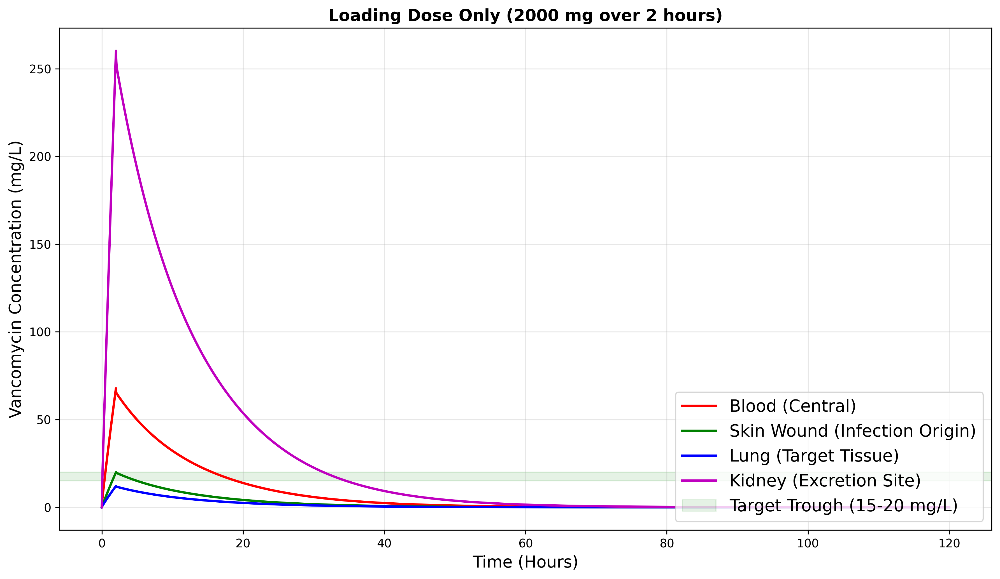

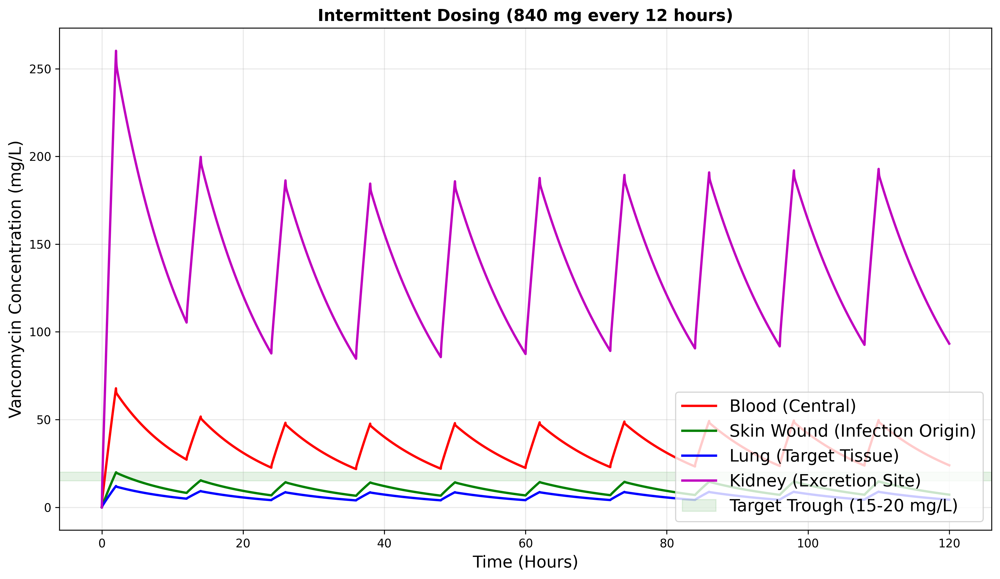

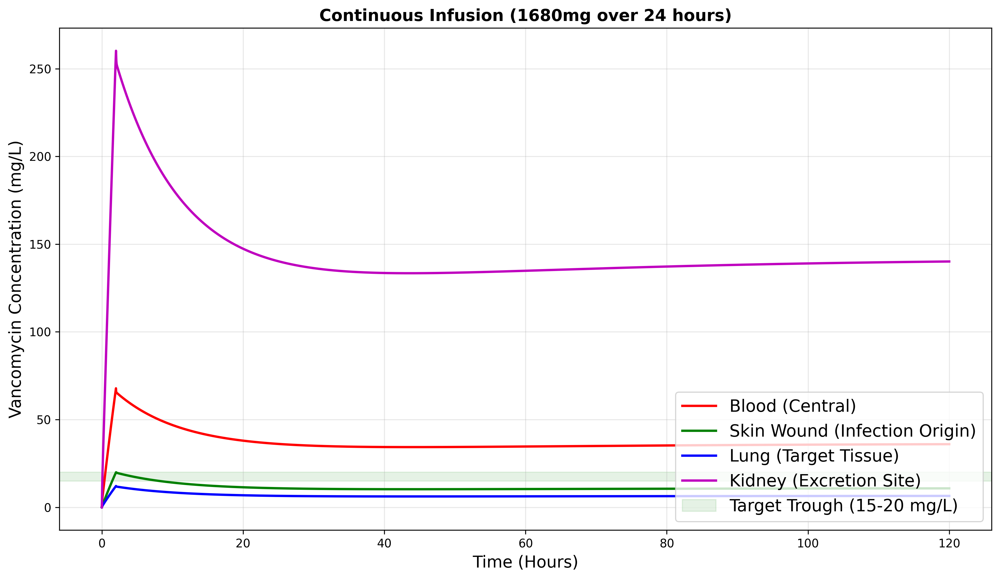

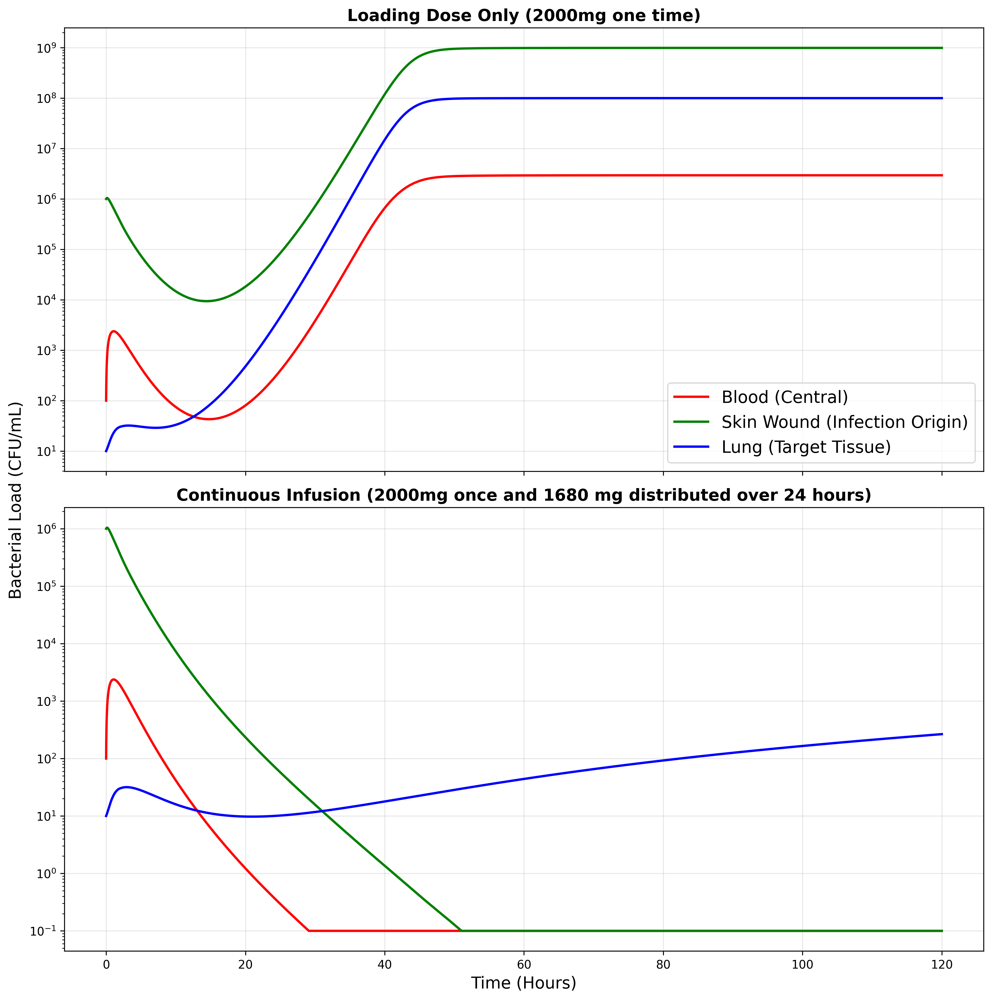

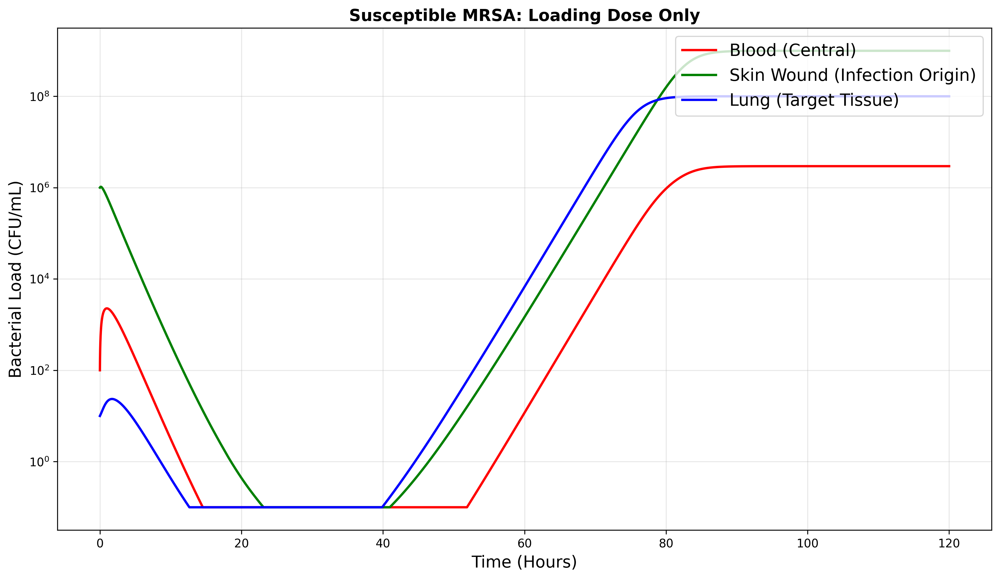

...

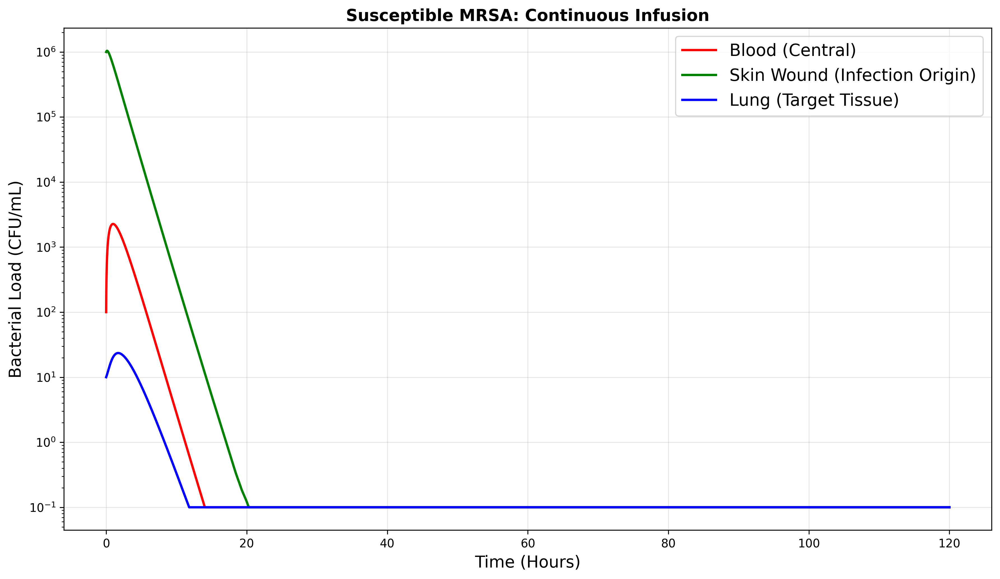

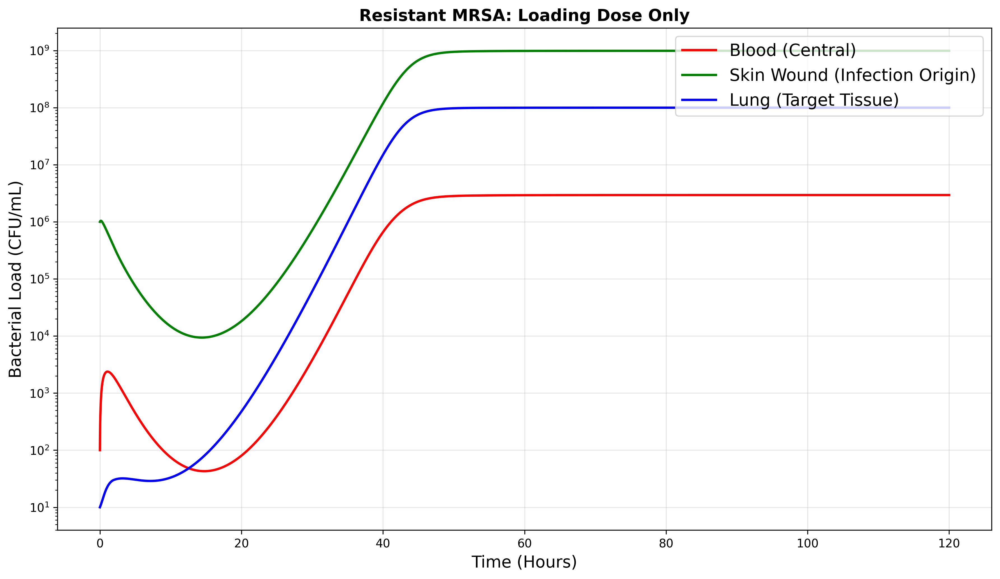

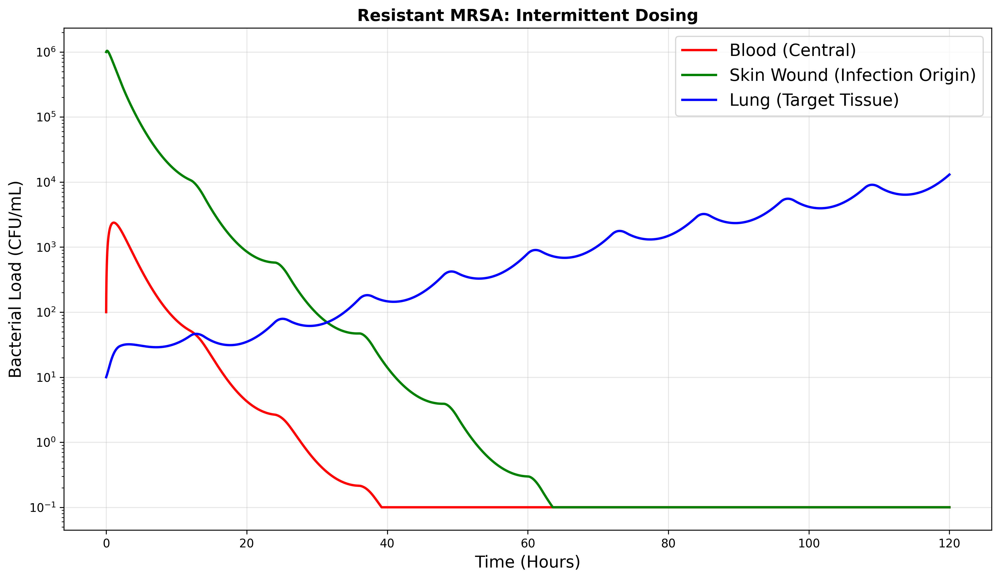

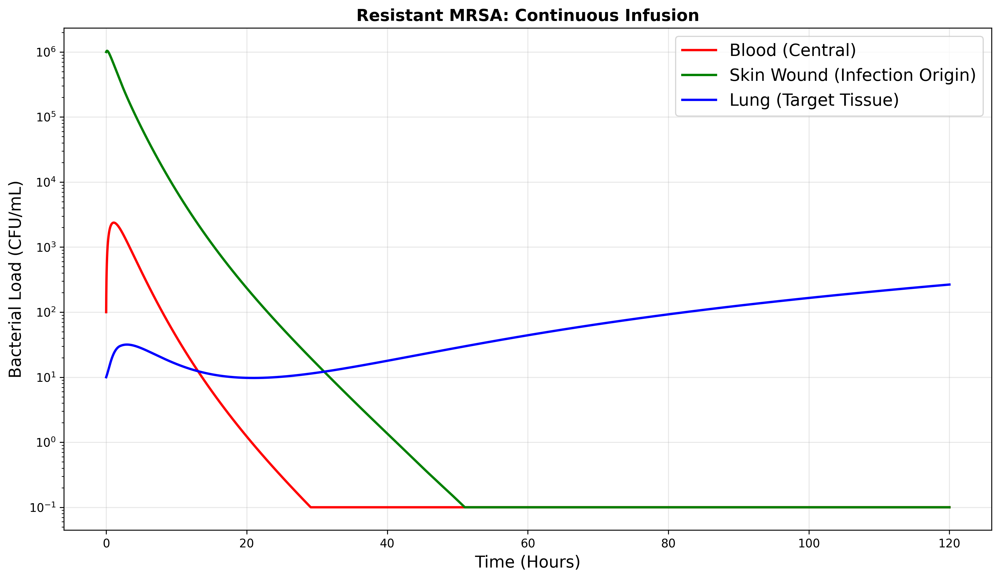

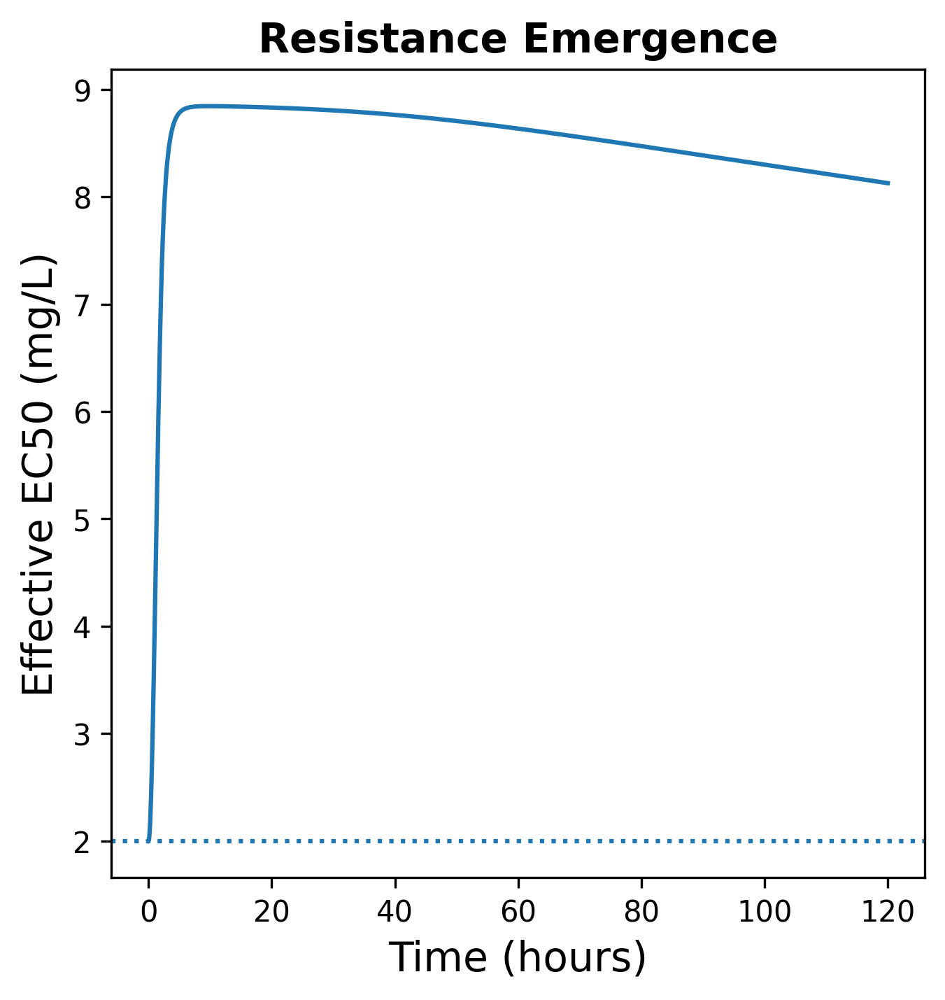

<Figure size 1500x1500 with 0 Axes>

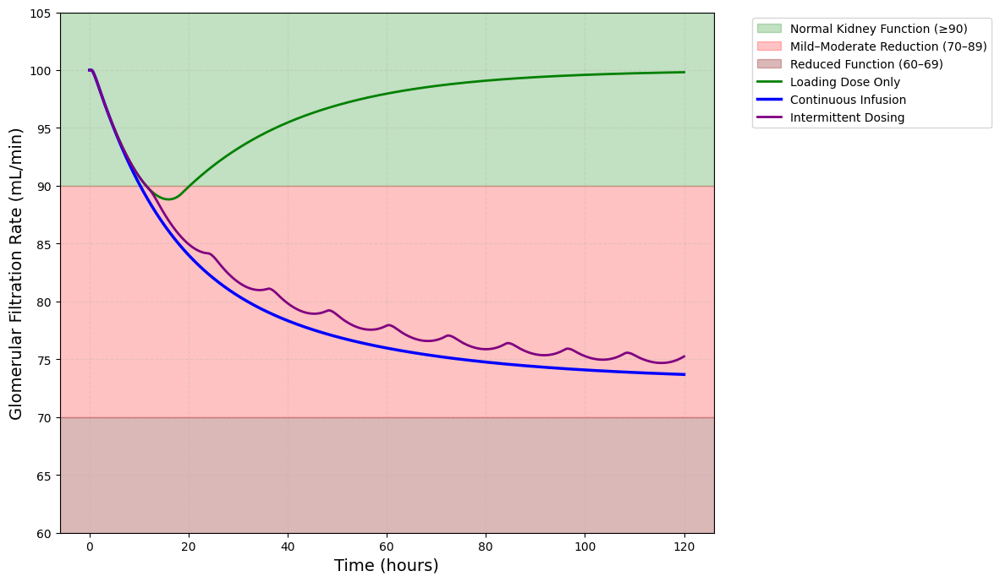

In [ ]:
sol_load_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_loading_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_nores_cons = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_continuous_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_nores_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_no_resist, dose_intermittent_cons,), mxstep=10000,atol=atol, rtol=1e-6)

sol_load_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_loading_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_cont_res_cons = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_continuous_cons,), mxstep=10000,atol=atol, rtol=1e-6)
sol_int_res_cons  = odeint(vanco_mrsa_model, y0, t, args=(params_resist, dose_intermittent_cons,), mxstep=10000,atol=atol, rtol=1e-6)

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Loading Dose Only (2000 mg over 2 hours)", fontsize=14,fontweight='bold')
solutions = [sol_load_res_cons]
plt.plot(t, sol_load_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t, sol_load_res_cons[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_load_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t, sol_load_res_cons[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Intermittent Dosing (840 mg every 12 hours)", fontsize=14,fontweight='bold')
solutions = [sol_int_res_cons]
plt.plot(t, sol_int_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_int_res_cons[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_int_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_int_res_cons[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Continuous Infusion (1680mg over 24 hours)", fontsize=14,fontweight='bold')
plt.plot(t, sol_cont_res_cons[:, 0], 'r-', linewidth=2, label="Blood (Central)")
plt.plot(t,sol_cont_res_cons[:,1], 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.plot(t, sol_cont_res_cons[:, 3], 'b-', linewidth=2, label="Lung (Target Tissue)")
plt.plot(t,sol_cont_res_cons[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Vancomycin Concentration (mg/L)",fontsize=14)
plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, dpi = 300)
titles = ["Loading Dose Only (2000mg one time)", "Continuous Infusion (2000mg once and 1680 mg distributed over 24 hours)"]#, "Intermittent Dosing (1350mg q12h)"]
solutions = [sol_load_res_cons, sol_cont_res_cons]#, sol_int_res]
fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)

for ax, sol, title in zip(axes, solutions, titles):
    ax.semilogy(t, np.maximum(sol[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
    ax.semilogy(t,np.maximum(sol[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
    ax.semilogy(t, np.maximum(sol[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
    #ax.plot(t,sol[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.set_ylabel("Vancomycin Concentration (mg/L)")
    # Therapeutic Window for MRSA
    #ax.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
    #ax.axhline(y=10, color='gray', linestyle=':', label="MIC for MRSA (approx)")
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Time (Hours)",fontsize=14)
axes[0].legend(loc='lower right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Susceptible MRSA: Loading Dose Only", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_load_nores_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_nores_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Susceptible MRSA: Intermittent Dosing", fontsize=14,fontweight='bold')
solutions = [sol_int_res_cons]
#fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_int_nores_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_nores_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Susceptible MRSA: Continuous Infusion", fontsize=14,fontweight='bold')
#fig.supylabel("Bacterial Load (CFU/mL)",fontsize=14)
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_cont_nores_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_nores_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Resistant MRSA: Loading Dose Only", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_load_res_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_load_res_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Resistant MRSA: Intermittent Dosing", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_int_res_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_int_res_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7), dpi=300)
plt.title("Resistant MRSA: Continuous Infusion", fontsize=14,fontweight='bold')
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 5],1e-1), 'r-', linewidth=2, label="Blood (Central)")
plt.semilogy(t,np.maximum(sol_cont_res_cons[:,4],1e-1), 'g-', linewidth=2, label = "Skin Wound (Infection Origin)")
plt.semilogy(t, np.maximum(sol_cont_res_cons[:, 6],1e-1), 'b-', linewidth=2, label="Lung (Target Tissue)")
#plt.plot(t,sol_int_res[:,2], 'm-', linewidth=2, label = "Kidney (Excretion Site)")
plt.ylabel("Bacterial Load (CFU/mL)",fontsize=14)
#plt.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
plt.grid(alpha=0.3)
plt.xlabel("Time (Hours)",fontsize=14)
plt.legend(loc='upper right',fontsize='x-large')
plt.tight_layout()
plt.show()

AR_on = sol_load_res_cons[:, 7]
EC50_effective = params['EC50_0'] * (1 + params['Slp_AR'] * AR_on)
plt.figure(figsize=(5,5),dpi=300)
plt.plot(t, EC50_effective, label="Effective EC50")
plt.axhline(y=params['EC50_0'], ls=':', label="Baseline EC50")
plt.title("Resistance Emergence", fontsize=14,fontweight='bold')
plt.ylabel("Effective EC50 (mg/L)",fontsize=14)
plt.xlabel("Time (hours)",fontsize=14)

plt.figure(figsize=(5,5), dpi=300)

plt.figure(figsize=(12, 7))

# --- Kidney Function Zones (3 segments) ---
plt.axhspan(90, 105, color='green',  alpha=0.24, label='Normal Kidney Function (≥90)')
plt.axhspan(70, 90,  color='red', alpha=0.24, label='Mild–Moderate Reduction (70–89)')
plt.axhspan(60, 70,  color='maroon',    alpha=0.28, label='Reduced Function (60–69)')

# --- Plot Your Simulation Results ---
plt.plot(t, sol_load_res_cons[:, 13], label="Loading Dose Only",   color='green',   lw=2)
plt.plot(t, sol_cont_res_cons[:, 13], label="Continuous Infusion", color='blue',    lw=2.5)
plt.plot(t, sol_int_res_cons[:, 13],  label="Intermittent Dosing", color='purple', lw=2)

# --- Formatting ---
#plt.title('GFR vs. Time in Response to Dosing Regimens', fontsize=16, fontweight='bold')
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Glomerular Filtration Rate (mL/min)', fontsize=14)

plt.ylim(60, 105)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def mrsa_growth_model(N, t, params):
    N_blood, N_skin, N_lung = N
    mu = params['mu']
    K = params['K']
    migrate = params['migration_rate']

    # ODEs
    dN_skin_dt = mu['skin'] * N_skin * (1 - N_skin/K['skin']) - migrate * N_skin
    dN_blood_dt = mu['blood'] * N_blood * (1 - N_blood/K['blood']) + migrate * N_skin - migrate * N_lung
    dN_lung_dt = mu['lung'] * N_lung * (1 - N_lung/K['lung']) + migrate * N_blood * 0.5

    return [dN_blood_dt, dN_skin_dt, dN_lung_dt]

# Parameters
params = {
    'mu': {'blood': 0.1, 'skin': 0.5, 'lung': 0.6},
    'K': {'blood': 1e5, 'skin': 1e9, 'lung': 1e8},
    'migration_rate': 0.05
}

t = np.linspace(0, 120, 1000)
N0 = [0, 1000, 0]   # 3 compartments: blood, skin, lung
sepsis_threshold = 1e5

sol = odeint(mrsa_growth_model, N0, t, args=(params,))
labels = ['Blood', 'Skin', 'Lung']
colors = ['red', 'green', 'blue']

# --- COMPOSITE GRAPH ---
plt.figure(figsize=(12, 7))
for i in range(3):
    plt.semilogy(t, sol[:, i], lw=3, color=colors[i], label=labels[i])

plt.axhline(y=sepsis_threshold, color='black', linestyle=':', alpha=0.5)
plt.fill_between(t, sepsis_threshold, 1e10, color='red', alpha=0.1, zorder=0)

plt.title('Composite MRSA Growth: Untreated Infection (90kg Male)', fontsize=16)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Bacterial Population (CFU) - Log Scale', fontsize=12)
plt.ylim(1, 1e10)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=12)
plt.show()

'''
# --- 4 SUBPLOTS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    axes[i].semilogy(t, sol[:, i], lw=2.5, color=colors[i])
    axes[i].set_title(f'MRSA Population: {labels[i]}', fontsize=14)
    axes[i].set_ylabel('Total CFU (Log Scale)')
    axes[i].set_xlabel('Time (hrs)')
    axes[i].grid(True, which="both", alpha=0.3)

    # Sepsis shading for subplots
    axes[i].axhline(y=sepsis_threshold, color='black', linestyle=':', alpha=0.5)
    axes[i].fill_between(t, sepsis_threshold, 1e10, color='red', alpha=0.1, zorder=0)
    axes[i].set_ylim(1, 1e10)

plt.tight_layout()
plt.show()
'''

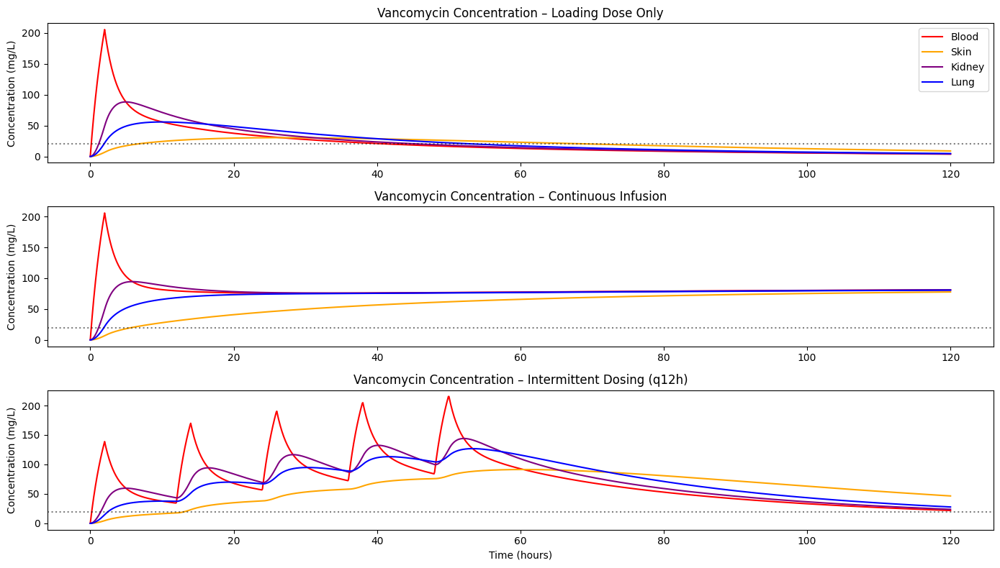

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# --- PK parameters (conceptual, not clinical) ---
kel = 0.104        # elimination rate (1/hr): this uses MUSC guidelines while assuming CrCl = 120
k_bk = 0.25       # blood <-> kidney (1/hr): all these uses t(1/2)= ln(1/2)/k equation
k_bl = 0.1     # blood <-> lung (1/hr)
k_bs = 0.03       # blood <-> skin (1/hr)

Vc = 6.50         # central (blood) volume in L

# --- Dosing regimens (mg/hr into central compartment) ---

# 1) Loading dose: 2000 mg over 1 hour (20-25 mg/kg with max at 2000)
def dose_loading(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 0.0

# 2) Continuous infusion: 1350 mg per 24h (15 mg/kg)
def dose_continuous(t):
    if 0 <= t < 2:
        return 1000.0  # mg/hr
    return 1350.0 / 24.0  # mg/hr

# 3) Intermittent dosing: 1350 mg over 2 hrs every 12h (0–1, 12–13, 24–25, ...)
def dose_intermittent(t):
    if any(0 <= t - start < 2 for start in [0, 12, 24, 36, 48]):
        return 675.0  # mg/hr
    return 0.0

# --- ODE system: concentrations in mg/L ---
def vanco_pk(C, t, dose_fn):
    Cb, Cs, Ck, Cl = C  # blood, skin, kidney, lung (all mg/L)

    input_mg_per_hr = dose_fn(t)
    input_term = input_mg_per_hr / Vc  # mg/hr ÷ L = mg/L/hr

    dCb_dt = (
        -kel * Cb
        - k_bk * (Cb - Ck)
        - k_bl * (Cb - Cl)
        - k_bs * (Cb - Cs)
        + input_term
    )

    dCs_dt = k_bs * (Cb - Cs)
    dCk_dt = k_bk * (Cb - Ck)
    dCl_dt = k_bl * (Cb - Cl)

    return [dCb_dt, dCs_dt, dCk_dt, dCl_dt]

# --- Simulation setup ---
t = np.linspace(0, 120, 1500)  # 120 hours
C0 = [0.0, 0.0, 0.0, 0.0]     # starting with no drug

# Run simulations
sol_load = odeint(vanco_pk, C0, t, args=(dose_loading,))
sol_cont = odeint(vanco_pk, C0, t, args=(dose_continuous,))
sol_int = odeint(vanco_pk, C0, t, args=(dose_intermittent,))

labels = ["Blood", "Skin", "Kidney", "Lung"]
colors = ["red", "orange", "purple", "blue"]

# --- Plotting ---
plt.figure(figsize=(14, 8))

# Loading dose
plt.subplot(3, 1, 1)
for i in range(4):
    plt.plot(t, sol_load[:, i], color=colors[i], label=labels[i])
plt.title("Vancomycin Concentration – Loading Dose Only")
plt.ylabel("Concentration (mg/L)")
plt.axhline(y=20, color='black', linestyle=':', alpha=0.5)
plt.legend()

# Continuous infusion
plt.subplot(3, 1, 2)
for i in range(4):
    plt.plot(t, sol_cont[:, i], color=colors[i], label=labels[i])
plt.title("Vancomycin Concentration – Continuous Infusion")
plt.ylabel("Concentration (mg/L)")
plt.axhline(y=20, color='black', linestyle=':', alpha=0.5)

# Intermittent dosing
plt.subplot(3, 1, 3)
for i in range(4):
    plt.plot(t, sol_int[:, i], color=colors[i], label=labels[i])
plt.title("Vancomycin Concentration – Intermittent Dosing (q12h)")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/L)")
plt.axhline(y=20, color='black', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

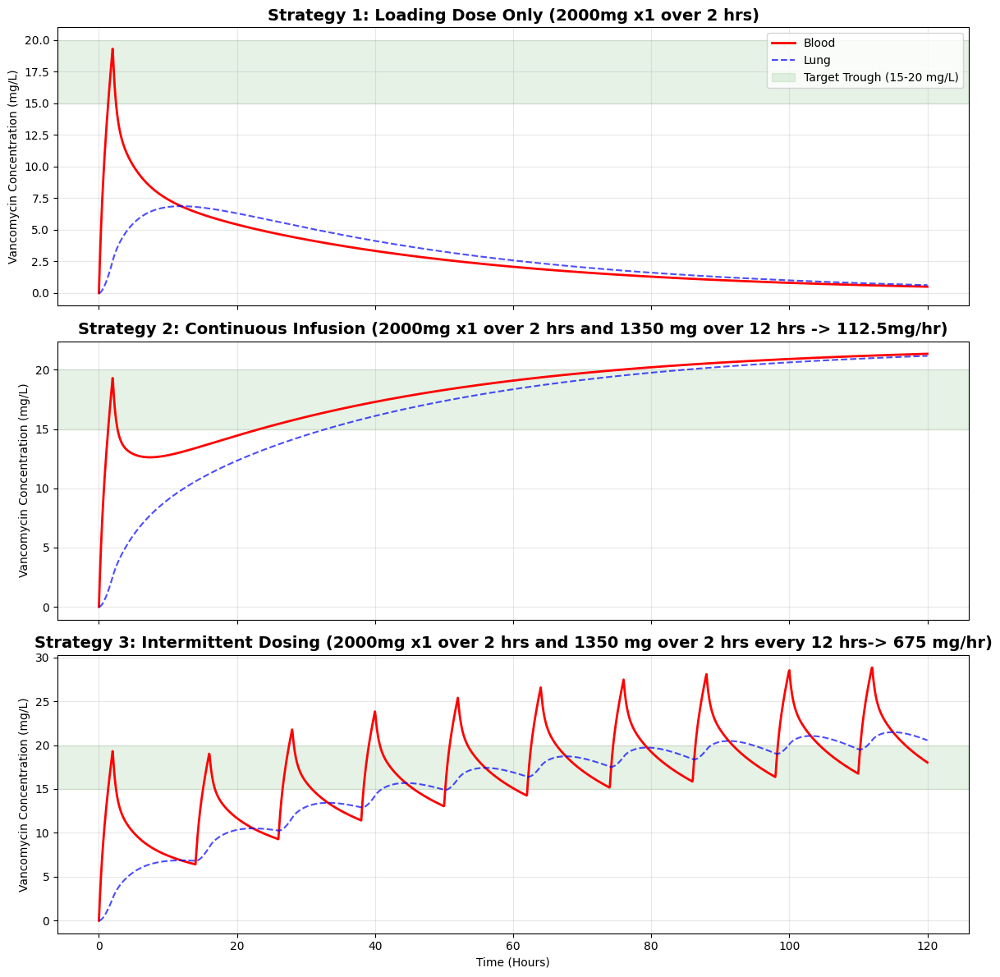

In [ ]:
#NEW CODE FOR VANCO VS TIME
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# --- PK parameters (Clinically Informed) ---
# Assuming 70kg patient with normal renal function
Vc = 49.0          # Central Volume (0.7 L/kg * 70kg): SHC
kel = 0.104        # Elimination rate (corresponds to t1/2 of ~6.7 hrs)

# Inter-compartmental clearance rates (Adjusted for physiological feasibility)
k_bs = 0.20        # Skin (George et al)
k_bk = 1        # Kidney tissue
k_bl = 0.12        # Lung tissue (George et al)

# --- Dosing regimens (mg/hr into central compartment) ---

# 1) Loading dose only: 2000 mg over 2 hours
def dose_loading(t):
    if 0 <= t < 2:
        return 1000.0  # 1000mg/hr * 2hr = 2000mg
    return 0.0

# 2) Continuous infusion: Loading dose + 1350 mg/12h (Standard for MRSA)
def dose_continuous(t):
    if 0 <= t < 2:
        return 1000.0
    return 1350.0 / 12.0  # 15mg/kg, q12, UNMC

# 3) Intermittent dosing: 1350 mg every 12h (Traditional approach)
def dose_intermittent(t):
    # Loading dose: 1000 mg over 2 hours (0–2 hr)
    if 0 <= t < 2:
        return 1000.0

    if t >= 14:
        # Time since first intermittent dose
        dt = t - 14
        cycle = dt % 12
        if 0 <= cycle < 2:
            return 675.0  # 675 mg/hr × 2 hr = 1350 mg

    return 0.0

# --- ODE system ---
def vanco_pk(C, t, dose_fn):
    Cb, Cs, Ck, Cl = C
    input_term = dose_fn(t) / Vc

    # Central Compartment (Blood)
    dCb_dt = (
        -kel * Cb
        - k_bs * (Cb - Cs)
        - k_bk * (Cb - Ck)
        - k_bl * (Cb - Cl)
        + input_term
    )

    # Peripheral Compartments
    dCs_dt = k_bs * (Cb - Cs)
    dCk_dt = k_bk * (Cb - Ck)
    dCl_dt = k_bl * (Cb - Cl)

    return [dCb_dt, dCs_dt, dCk_dt, dCl_dt]

# --- Simulation ---
t = np.linspace(0, 120, 2000) # 100 Hour window
C0 = [0.0, 0.0, 0.0, 0.0]

sol_load = odeint(vanco_pk, C0, t, args=(dose_loading,))
sol_cont = odeint(vanco_pk, C0, t, args=(dose_continuous,))
sol_int = odeint(vanco_pk, C0, t, args=(dose_intermittent,))

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
titles = ["Strategy 1: Loading Dose Only (2000mg x1 over 2 hrs)", "Strategy 2: Continuous Infusion (2000mg x1 over 2 hrs and 1350 mg over 12 hrs -> 112.5mg/hr)", "Strategy 3: Intermittent Dosing (2000mg x1 over 2 hrs and 1350 mg over 2 hrs every 12 hrs-> 675 mg/hr)"]
solutions = [sol_load, sol_cont, sol_int]

for ax, sol, title in zip(axes, solutions, titles):
    ax.plot(t, sol[:, 0], 'r-', linewidth=2, label="Blood")
    ax.plot(t, sol[:, 3], 'b--', alpha=0.7, label="Lung")
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Vancomycin Concentration (mg/L)")
    # Therapeutic Window for MRSA
    ax.axhspan(15, 20, color='green', alpha=0.1, label="Target Trough (15-20 mg/L)")
    ax.grid(alpha=0.3)

axes[2].set_xlabel("Time (Hours)")
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

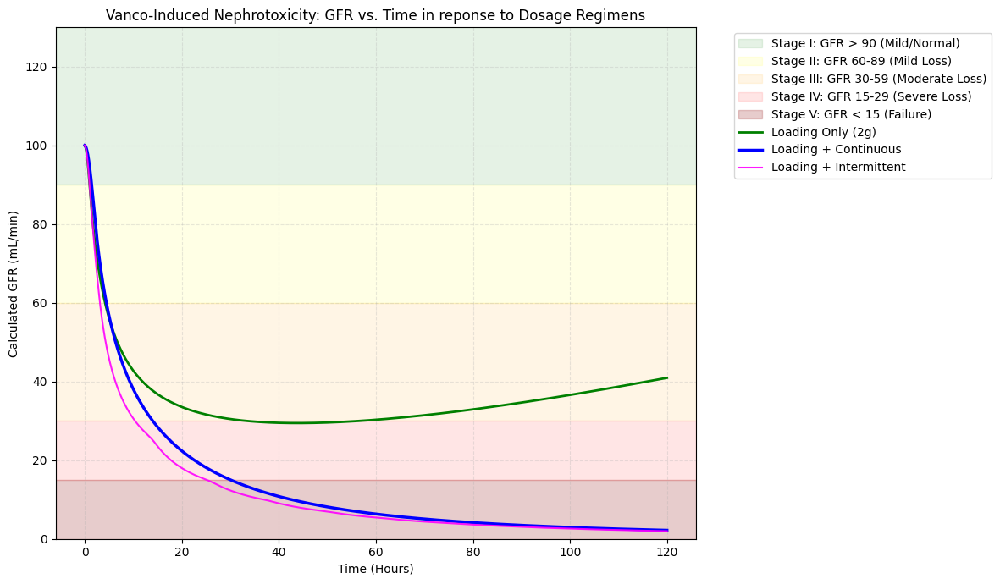

In [ ]:
# EXPLORATORY GFR CODE (No mass balance)
import numpy as np
import matplotlib.pyplot as plt

# --- Patient & PK Parameters ---
age = 45
base_gfr = 100.0
base_SCr = 1.0
weight = (base_gfr * 72 * base_SCr) / (140 - age)

Vd = 45.0
hours = 120
dt = 0.05
t = np.arange(0, hours, dt)

# --- Toxicity Constants (Calibrated to show movement across stages) ---
sensitivity = 0.005
recovery_rate = 0.01

def simulate_regimen(mode):
    conc = np.zeros(len(t))
    scr = np.full(len(t), base_SCr)
    gfr = np.zeros(len(t))

    for i in range(1, len(t)):
        rate = 0
        if mode == 'loading_only':
            if t[i] <= 1: rate = 2000
        elif mode == 'continuous':
            if t[i] <= 2: rate = 1000
            else: rate = 1350 / 12
        elif mode == 'intermittent':
            if t[i] <= 1: rate = 2000
            else:
                cycle_pos = (t[i] - 1) % 12
                if cycle_pos <= 2: rate = 1350 / 2

        # 1. Cockcroft-Gault GFR Calculation
        current_gfr = ((140 - age) * weight) / (72 * scr[i-1])
        gfr[i-1] = current_gfr

        # 2. Vancomycin Concentration (Clearance tied to current GFR)
        cl_vanco = (current_gfr * 60) / 1000
        ke = cl_vanco / Vd
        dC = (rate/Vd - ke * conc[i-1]) * dt
        conc[i] = max(0, conc[i-1] + dC)

        # 3. Creatinine Response
        dSCr = (sensitivity * conc[i] - recovery_rate * (scr[i-1] - base_SCr)) * dt
        scr[i] = max(0.5, scr[i-1] + dSCr)

    gfr[-1] = ((140 - age) * weight) / (72 * scr[-1])
    return gfr

# Run simulations
gfr_load = simulate_regimen('loading_only')
gfr_cont = simulate_regimen('continuous')
gfr_int  = simulate_regimen('intermittent')

# --- Plotting with Kidney Disease Stages ---
plt.figure(figsize=(12, 7))

# Define Stage Backgrounds
plt.axhspan(90, 130, color='green', alpha=0.1, label='Stage I: GFR > 90 (Mild/Normal)')
plt.axhspan(60, 90,  color='yellow', alpha=0.1, label='Stage II: GFR 60-89 (Mild Loss)')
plt.axhspan(30, 60,  color='orange', alpha=0.1, label='Stage III: GFR 30-59 (Moderate Loss)')
plt.axhspan(15, 30,  color='red', alpha=0.1, label='Stage IV: GFR 15-29 (Severe Loss)')
plt.axhspan(0, 15,   color='darkred', alpha=0.2, label='Stage V: GFR < 15 (Failure)')

# Plot Dosage Curves
plt.plot(t, gfr_load, label='Loading Only (2g)', color='green', lw=2)
plt.plot(t, gfr_cont, label='Loading + Continuous', color='blue', lw=2.5)
plt.plot(t, gfr_int,  label='Loading + Intermittent', color='magenta', alpha=0.9)

# Formatting
plt.title('Vanco-Induced Nephrotoxicity: GFR vs. Time in reponse to Dosage Regimens')
plt.xlabel('Time (Hours)')
plt.ylabel('Calculated GFR (mL/min)')
plt.ylim(0, 130)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Histamine Graphs

/tmp/ipykernel_398/63872409.py:19: RuntimeWarning: overflow encountered in exp
  return np.where(t_local >= 0, np.exp(-k_decay * t_local) - np.exp(-k_rise * t_local), 0)


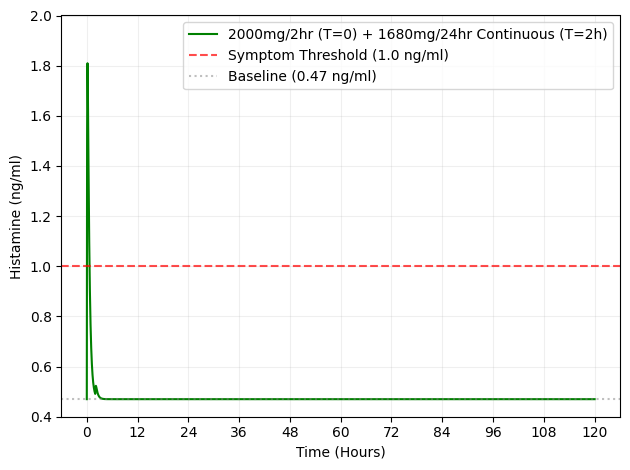

Loading Peak: 1.81 ng/ml
Maintenance Peak (Int): 0.89 ng/ml
Maintenance Level (Cont): 0.47 ng/ml


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
k_decay = 0.04
k_rise = 0.2
baseline = 0.47
weight = 77.4  # Reference weight (kg)
a_norm = 0.0833  # Scaling constant for mg/kg/hr
b = 1.33        # Exponent for rate sensitivity

# Functions
def S_normalized(R_norm):
    """Calculates scaling factor based on mg/kg/hr rate"""
    return a_norm * (R_norm**b)

def f_spike(t_local):
    """Base Bateman function for rise and decay kinetics"""
    return np.where(t_local >= 0, np.exp(-k_decay * t_local) - np.exp(-k_rise * t_local), 0)

# Time setup: 120 hours
t_hrs = np.linspace(0, 120, 10000)
t_mins = t_hrs * 60

# Strategy 1: Loading dose only (2000mg/2hr)
R_load_norm = (2000 / 2) / weight  # 12.92 mg/kg/hr
s1_curve = S_normalized(R_load_norm) * f_spike(t_mins) + baseline

# Strategy 2: Loading + Continuous (2100mg/24hr)
R_cont_norm = (1680 / 24) / weight  # 1.25 mg/kg/hr
s2_curve = (S_normalized(R_load_norm) * f_spike(t_mins) +
            S_normalized(R_cont_norm) * f_spike(t_mins - 120) + baseline)

# Strategy 3: Loading + Intermittent (1050mg/2hr Q12H)
R_int_norm = (840 / 2) / weight  # 8.72 mg/kg/hr
starts_hrs = [0, 2, 14, 26, 38, 50, 62, 74, 86, 98, 110]
s3_curve = np.full_like(t_mins, baseline)
# Loading spike
s3_curve += S_normalized(R_load_norm) * f_spike(t_mins)
# Intermittent maintenance spikes
for start_h in starts_hrs[1:]:
    s3_curve += S_normalized(R_int_norm) * f_spike(t_mins - start_h * 60)

# Plotting
#fig, axes = plt.subplots(1, 1, figsize=(12, 14), sharex=True)
fig, axes = plt.subplots(1, 1)

strategies = [
    #("Strategy 1: Loading Dose Only", "2000mg / 2hr at T=0", s1_curve, 'black')
    ("Strategy 4: Load + Lowered Continuous", "2000mg/2hr (T=0) + 1680mg/24hr Continuous (T=2h)", s2_curve, 'green'),
    #("Strategy 4: Load + Lowered Intermittent", "2000mg/2hr (T=0) + 840mg/2hr Q12H (T=2h, 14h, ...)", s3_curve, 'blue')
]

for i, (title, subtitle, data, color) in enumerate(strategies):
    ax = plt
    ax.plot(t_hrs, data, color=color, linewidth=1.5, label=subtitle)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label="Symptom Threshold (1.0 ng/ml)")
    ax.axhline(y=0.47, color='gray', linestyle=':', alpha=0.5, label="Baseline (0.47 ng/ml)")

    #ax.title(f"{title}", fontsize=16,)
    ax.ylabel("Histamine (ng/ml)")
    ax.grid(True, alpha=0.2)
    ax.ylim(0.4, 2.0)
    ax.legend(loc='upper right', fontsize=10)

plt.xlabel("Time (Hours)")
plt.xticks(np.arange(0, 121, 12))
plt.tight_layout()
plt.show()
#plt.savefig("4")

# Output peaks for confirmation
print(f"Loading Peak: {np.max(s1_curve):.2f} ng/ml")
print(f"Maintenance Peak (Int): {np.max(s3_curve[t_hrs > 5]):.2f} ng/ml")
print(f"Maintenance Level (Cont): {np.max(s2_curve[t_hrs > 5]):.2f} ng/ml")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

### Notes

# differential between CA-MRSA and HA-MRSA (For this, I picked CA-MRSA)
# Experimental Modeling: In laboratory settings, CA-MRSA growth shows
# equation for exponential growth of a bacterial: dP/dt = rP(1 - P/k)
# distinct phases: lag (1h), exponential (2–5h), and stationary (10–24h)
# MRSA concentration in mrsa pneumonia cases 10^4 colony-forming units (CFU)/mL (or more)

# Parameters
K = 1e6          # CFU/swab (carrying capacity)
P0 = 1e2         # CFU/swab (initial colonized load)

def logistic_rhs(t, P, r, K):   # Logistic model: dP/dt = r * P * (1 - P/K)
    return r * P * (1 - P / K)

doubling_time_hours = 0.5                       # doubling time 30 mins
growth_rate_hr = np.log(2) / doubling_time_hours          # growth rate in hours
growth_rate_day = growth_rate_hr * 24                     # growth rate in days

dt = 0.001
t = np.arange(0, 7.001, dt)

P = np.zeros_like(t)
P[0] = P0

for i in range(1, len(t)):
    dPdt = logistic_rhs(t[i-1], P[i-1], growth_rate_day, K)
    P[i] = P[i-1] + dPdt * dt
    P[i] = min(max(P[i], 0.0), K)

### What to research
# carrying capacity/doubling time/initial value for the different units
# maybe incorporate the phases  of basterial growth stated above
# what would be a reasonable time period

plt.figure()
plt.plot(t, P)
plt.xlabel("Time (days)")
plt.ylabel("CA-MRSA load (CFU per swab)")
plt.title("Logistic growth model of CA-MRSA colonization over 7 days")
plt.yscale("log")  # helpful because CFU spans orders of magnitude
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

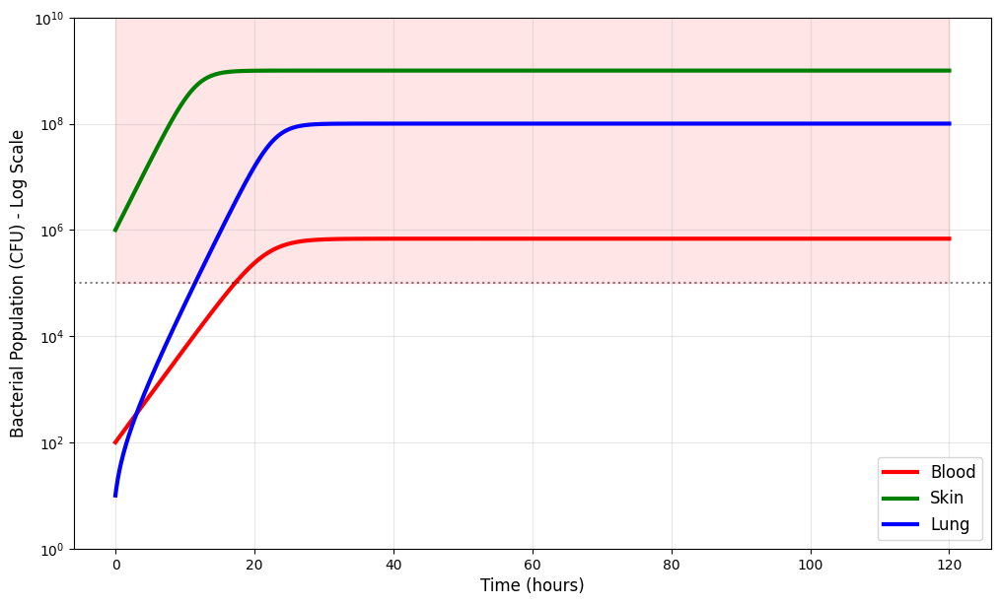

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def mrsa_growth_model(N, t, params):
    # State unpacking: [blood, skin, lung]
    N_blood, N_skin, N_lung = N

    mu = params['mu']
    K = params['K']
    #m = params['migration_rate']  # per hour
    #d = params['d']
    s = params['s']
    l = params['l']

    # Logistic growth in each compartment
    growth_blood = mu['blood'] * N_blood * (1 - N_blood / K['blood']) + s * N_blood - l * N_blood
    growth_skin  = mu['skin']  * N_skin  * (1 - N_skin  / K['skin']) - s * N_blood
    growth_lung  = mu['lung']  * N_lung  * (1 - N_lung  / K['lung']) + l * N_blood

    # Symmetric, mass-balanced migration:
    # skin ↔ blood, blood ↔ lung
    # flux_skin_blood = m * (N_skin - N_blood)
    # flux_blood_lung = m * (N_blood - N_lung)

    # flux_skin_blood = m * (N_skin - N_blood)
    # flux_blood_lung = m * (N_blood - N_lung)

    dN_skin_dt  = growth_skin  #- flux_skin_blood
    dN_blood_dt = growth_blood #+ flux_skin_blood - flux_blood_lung
    dN_lung_dt  = growth_lung  #+ flux_blood_lung

    return [dN_blood_dt, dN_skin_dt, dN_lung_dt]

# Parameters
params = {
    'mu': {
        'blood': 0.6,   # 1/h
        'skin':  0.6,   # 1/h
        'lung':  0.6    # 1/h
    },
    'K': {
        'blood': 1e6,   # CFU
        'skin':  1e9,   # CFU
        'lung':  1e8    # CFU
    },
    #'migration_rate': 0.05  # 1/h
    #'d': 0.5,
    's': 0.01,
    'l': 0.2

}

t = np.linspace(0, 120, 1000)
N0 = [1e2, 1e6, 1e1]   # [blood, skin, lung]
sepsis_threshold = 1e5

sol = odeint(mrsa_growth_model, N0, t, args=(params,))
labels = ['Blood', 'Skin', 'Lung']
colors = ['red', 'green', 'blue']

plt.figure(figsize=(12, 7))
for i in range(3):
    plt.semilogy(t, sol[:, i], lw=3, color=colors[i], label=labels[i])

plt.axhline(y=sepsis_threshold, color='black', linestyle=':', alpha=0.5)
plt.fill_between(t, sepsis_threshold, 1e10, color='red', alpha=0.1, zorder=0)

#plt.title('Composite MRSA Growth: Untreated Infection (70kg Male)', fontsize=16)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Bacterial Population (CFU) - Log Scale', fontsize=12)
plt.ylim(1, 1e10)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=12)
plt.show()

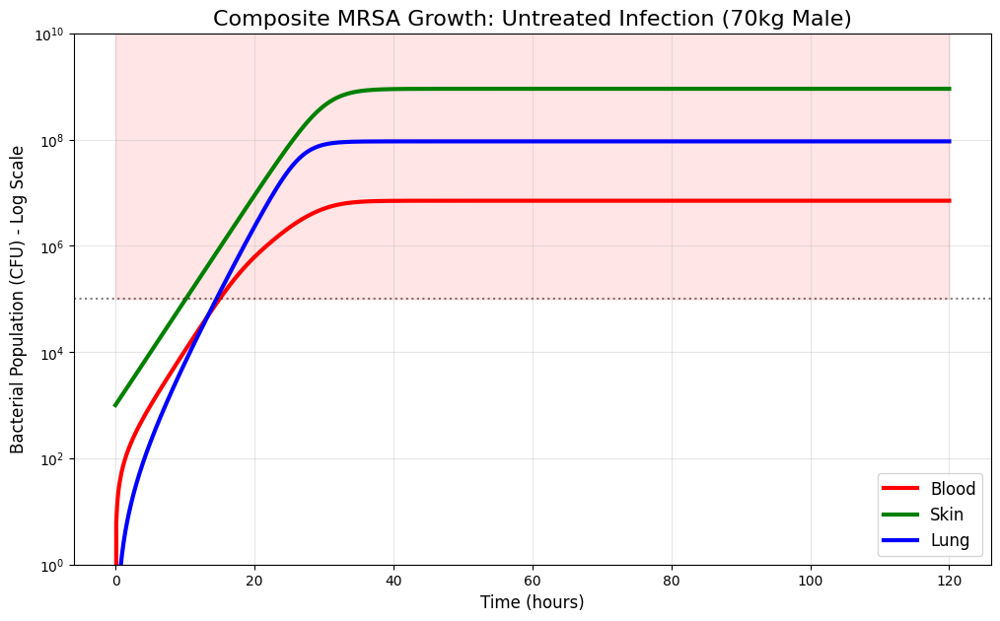

In [ ]:
# import numpy as np
# from scipy.integrate import odeint
# import matplotlib.pyplot as plt

# def mrsa_growth_model(N, t, params):
#     # State unpacking: [blood, skin, lung]
#     N_blood, N_skin, N_lung = N

#     mu = params['mu']
#     K = params['K']
#     m = params['migration_rate']  # per hour

#     # Logistic growth in each compartment
#     growth_blood = mu['blood'] * N_blood * (1 - N_blood / K['blood'])
#     growth_skin  = mu['skin']  * N_skin  * (1 - N_skin  / K['skin'])
#     growth_lung  = mu['lung']  * N_lung  * (1 - N_lung  / K['lung'])

#     # Symmetric, mass-balanced migration:
#     # skin ↔ blood, blood ↔ lung
#     # flux_skin_blood = m * (N_skin - N_blood)
#     # flux_blood_lung = m * (N_blood - N_lung)

#     flux_skin_blood = m * (N_skin - N_blood)
#     flux_blood_lung = m * (N_blood - N_lung)

#     dN_skin_dt  = growth_skin  - flux_skin_blood
#     dN_blood_dt = growth_blood + flux_skin_blood - flux_blood_lung
#     dN_lung_dt  = growth_lung  + flux_blood_lung

#     return [dN_blood_dt, dN_skin_dt, dN_lung_dt]

# # Parameters
# params = {
#     'mu': {
#         'blood': 0.1,   # 1/h
#         'skin':  0.5,   # 1/h
#         'lung':  0.6    # 1/h
#     },
#     'K': {
#         'blood': 1e5,   # CFU
#         'skin':  1e9,   # CFU
#         'lung':  1e8    # CFU
#     },
#     'migration_rate': 0.05  # 1/h
# }

# t = np.linspace(0, 120, 1000)
# N0 = [0, 1000, 0]   # [blood, skin, lung]
# sepsis_threshold = 1e5

# sol = odeint(mrsa_growth_model, N0, t, args=(params,))
# labels = ['Blood', 'Skin', 'Lung']
# colors = ['red', 'green', 'blue']

# plt.figure(figsize=(12, 7))
# for i in range(3):
#     plt.semilogy(t, sol[:, i], lw=3, color=colors[i], label=labels[i])

# plt.axhline(y=sepsis_threshold, color='black', linestyle=':', alpha=0.5)
# plt.fill_between(t, sepsis_threshold, 1e10, color='red', alpha=0.1, zorder=0)

# plt.title('Composite MRSA Growth: Untreated Infection (70kg Male)', fontsize=16)
# plt.xlabel('Time (hours)', fontsize=12)
# plt.ylabel('Bacterial Population (CFU) - Log Scale', fontsize=12)
# plt.ylim(1, 1e10)
# plt.grid(True, which="both", ls="-", alpha=0.3)
# plt.legend(fontsize=12)
# plt.show()